# Project 1: Supervised classification of coffee leaf diseases

**Official models:** SVM with RBF kernel, EfficientNet-B0 (fine-tuned)

**Task:** classify BRACOL leaf images by `predominant_stress` (six classes: Healthy, Miner, Rust, Phoma, Cercospora, Mixed)

**Representations:** (1) handcrafted colour / texture / edges, (2) frozen EfficientNet embeddings, plus end-to-end CNNs on raw images

The flow is: shared dataset corridor, then the full grading loop for SVM, then the same loop for EfficientNet. ResNet-50 and XGBoost are extras. Classes live in `p1_core.py` so the notebook stays readable and tests can import the same code.


## 1. Setup and imports

Use the **WSL** kernel so EfficientNet / ResNet see the RTX 4070 (CUDA). In Cursor: kernel picker → *Select Another Kernel* → *Python Environments* → `/home/alecs/pml_venv/bin/python` (display name **Python (PML WSL GPU)** if registered). The Windows `.venv` is CPU-only TensorFlow.


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from p1_core import (
    RANDOM_STATE, STRESS_NAMES, BRACOL_CLASSES, BRACOL_TO_STRESS,
    resolve_paths, save_and_show, report_compute,
    copy_missing_leaf_jpgs, extra_image_roots,
    LeafDataset, TrainValTestSplit,
    HandcraftedFeatures, FrozenDeepFeatures, PCAFeatures, scale_pack,
    SVMPipeline, XGBoostPipeline, EfficientNetPipeline, ResNetPipeline,
    ResidualMixedRule, fit_disease_probe, apply_residual_rule,
    load_bracol_labels, ensemble_average, classification_metrics,
    target_names_for,
)

rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PATHS = resolve_paths()
print("Data:", PATHS["data_dir"])
print("Figures:", PATHS["figures_dir"])
print("CSV exists:", os.path.isfile(PATHS["csv_path"]))
print("Image folder exists:", os.path.isdir(PATHS["image_dir"]))
# report_compute()


Data: /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-datasets/leaf
Figures: /mnt/c/Users/Alecs/PML/Project_1/figures
CSV exists: True
Image folder exists: True


## 2. Dataset corridor — extra images, then load

The official Mendeley zip is corrupted here, so the CSV has rows whose `{id}.jpg` is missing. Dataset Ninja hosts the same BRACOL leaf photos under the name **Coffee Leaf Biotic Stress** (Supervisely format, 500 images). We download that dump, then also copy any still-missing ids from the Roboflow/YOLO exports already on disk (`123_jpg.rf....jpg` → `123.jpg`). Count missing and corrupt files at runtime; do not hard-code 1,402.


In [4]:
# ninja_dir = PATHS["ninja_dir"]
# os.makedirs(ninja_dir, exist_ok=True)

# def _ninja_has_jpegs(root):
#     if not os.path.isdir(root):
#         return False
#     for dirpath, _, files in os.walk(root):
#         if any(name.lower().endswith(".jpg") for name in files):
#             return True
#     return False

# if not _ninja_has_jpegs(ninja_dir):
#     try:
#         import dataset_tools as dtools
#     except ImportError:
#         import subprocess, sys
#         subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "dataset-tools"])
#         import dataset_tools as dtools
#     try:
#         # Dataset Ninja listing name. "BRACOL" is the Mendeley title for the same collection.
#         dtools.download(dataset="Coffee Leaf Biotic Stress", dst_dir=ninja_dir)
#     except Exception as e:
#         print("Dataset Ninja download failed:", e)
#         print("Will still copy missing ids from YOLO/Roboflow folders on disk.")

# n_copied = copy_missing_leaf_jpgs(
#     PATHS["csv_path"], PATHS["image_dir"], extra_image_roots(PATHS),
# )
# print("Copied missing leaf JPEGs:", n_copied)
# if n_copied:
#     for fname in ("handcrafted.npz", "frozen_deep.npz"):
#         p = os.path.join(PATHS["features_dir"], fname)
#         if os.path.isfile(p):
#             os.remove(p)
#             print("Deleted stale feature cache:", p)

dataset = LeafDataset(PATHS["csv_path"], PATHS["image_dir"], check_jpeg=True)
df = dataset.load_and_match()
summary = dataset.eda_summary()
# print(json.dumps({k: v for k, v in summary.items() if k != "class_counts"}, indent=2))
print("Class counts:", summary["class_counts"])
# print("Corrupt ids:", dataset.corrupt_ids)
print(df.head())


Class counts: {0: 272, 1: 387, 2: 531, 3: 348, 4: 147, 5: 62}
   id  predominant_stress  miner  rust  phoma  cercospora  severity  \
0   1                   0      0     0      0           0         0   
1   2                   0      0     0      0           0         0   
2   3                   0      0     0      0           0         0   
3   4                   0      0     0      0           0         0   
4   5                   0      0     0      0           0         0   

                                          image_path  
0  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
1  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
2  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
3  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
4  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  


## 3. Exploratory plots


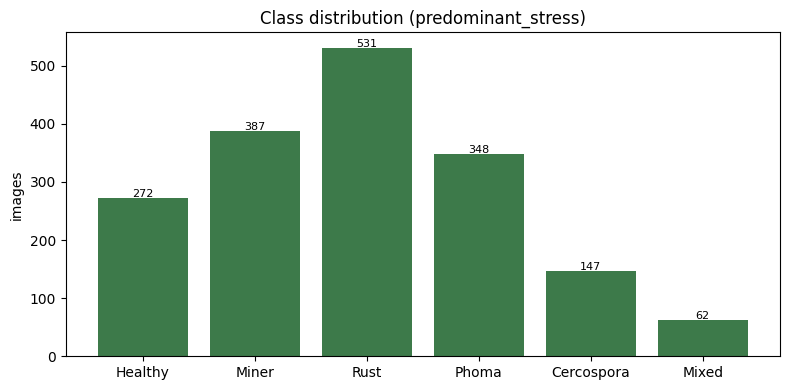

Saved class_distribution.png


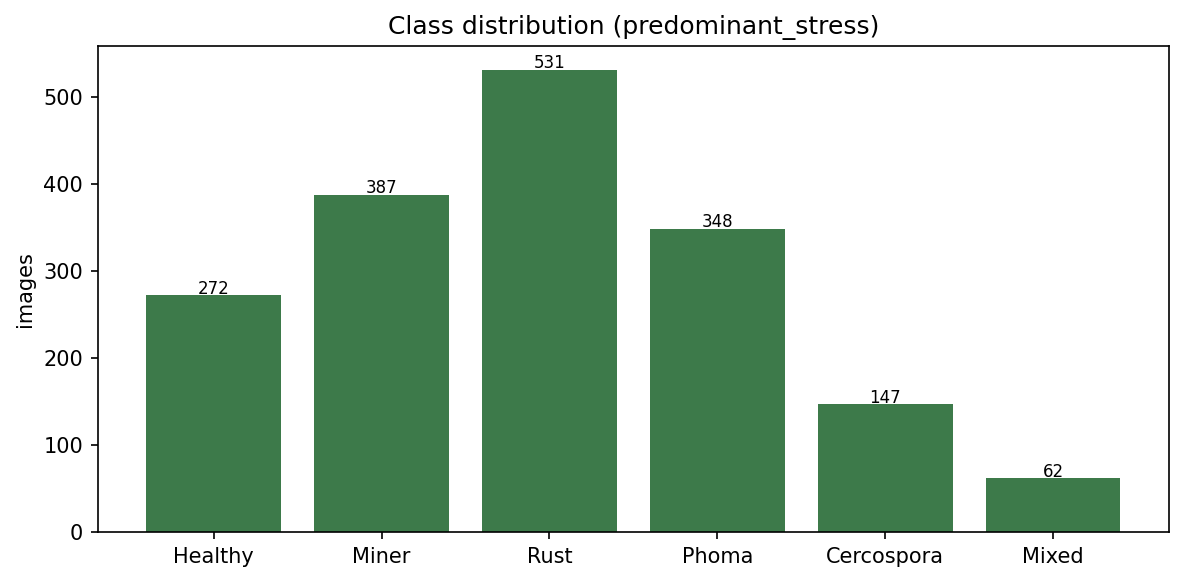

In [5]:
counts = dataset.class_counts()
fig, ax = plt.subplots(figsize=(8, 4))
names = [STRESS_NAMES.get(int(i), str(i)) for i in counts.index]
ax.bar(names, counts.values, color="#3d7a4a")
ax.set_ylabel("images")
ax.set_title("Class distribution (predominant_stress)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(int(v)), ha="center", fontsize=8)
fig.tight_layout()
save_and_show(fig, "class_distribution.png", PATHS["figures_dir"])
print("Saved class_distribution.png")


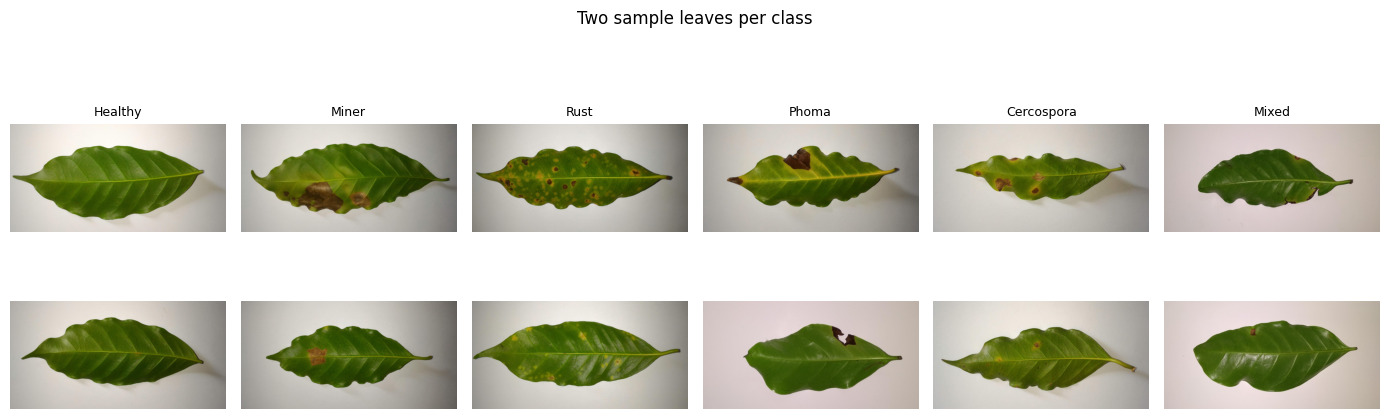

'/mnt/c/Users/Alecs/PML/Project_1/figures/sample_images.png'

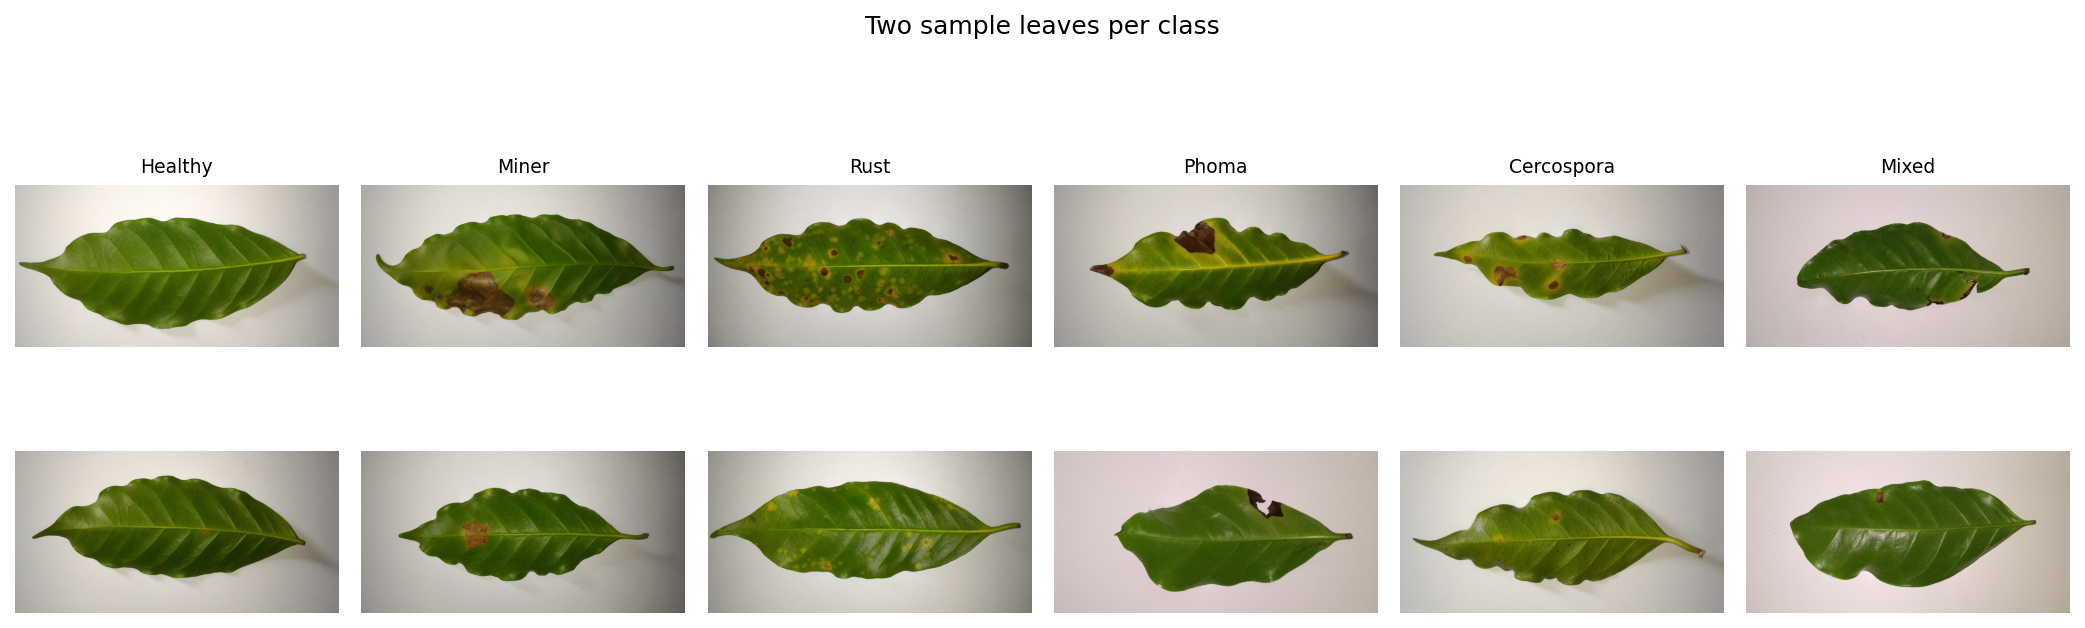

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for col, label in enumerate(sorted(df["predominant_stress"].unique())):
    sub = df[df["predominant_stress"] == label]
    for row in range(2):
        ax = axes[row, col]
        sample = sub.iloc[row % len(sub)]
        img = plt.imread(sample["image_path"])
        ax.imshow(img)
        ax.axis("off")
        if row == 0:
            ax.set_title(STRESS_NAMES.get(int(label), str(label)), fontsize=9)
fig.suptitle("Two sample leaves per class")
fig.tight_layout()
save_and_show(fig, "sample_images.png", PATHS["figures_dir"])


In [10]:
from PIL import Image as PILImage

with PILImage.open(df["image_path"].iloc[0]) as im:
    w, h = im.size
print(f"Native size: {w} x {h}. All current leaf JPEGs share this size; the models resize to 224 x 224.")


Native size: 2048 x 1024. All current leaf JPEGs share this size; the models resize to 224 x 224.


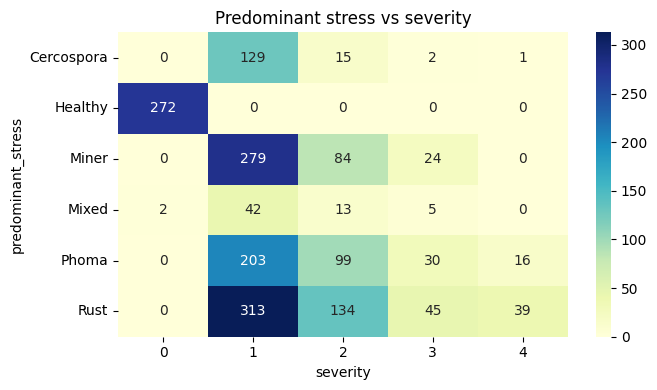

'/mnt/c/Users/Alecs/PML/Project_1/figures/eda_heatmaps.png'

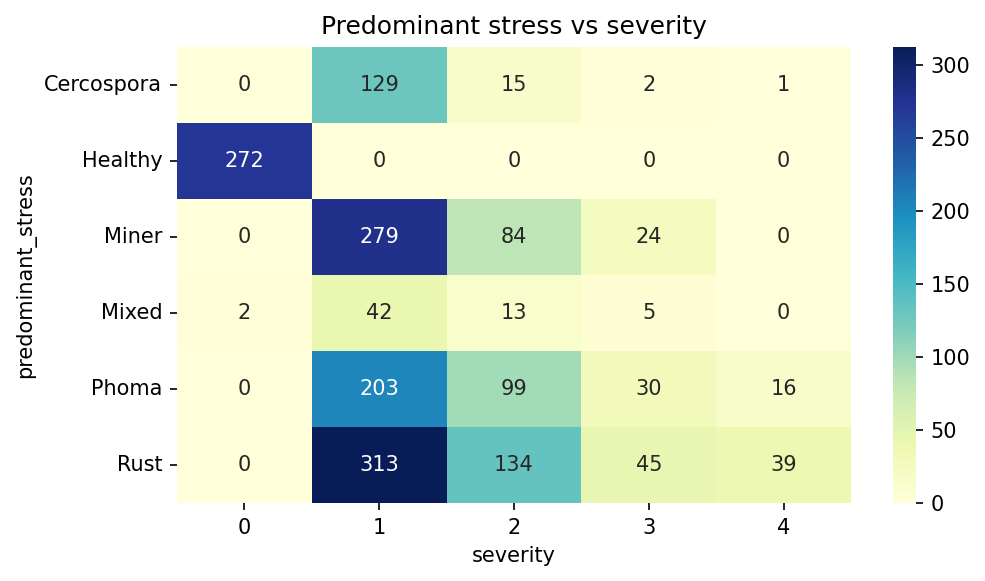

In [11]:
ct = pd.crosstab(df["predominant_stress"].map(STRESS_NAMES), df["severity"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Predominant stress vs severity")
fig.tight_layout()
save_and_show(fig, "eda_heatmaps.png", PATHS["figures_dir"])


A perceptual-hash scan on the current leaf files found **no duplicate groups**, so that check is omitted from the run. If you add a new dump of images, call `dataset.find_duplicates()` again.


## 4. Train / validation / test split (criterion h)

Stratified 70 / 15 / 15. The same indices are saved and reused by every model. Hyperparameters are chosen on validation only. Test is used once, after the config is locked.


In [12]:
split_path = os.path.join(PATHS["features_dir"], "split_ids.npz")
# Rebuild if you change the seed or the filtered table.
if os.path.exists(split_path):
    os.remove(split_path)
split = TrainValTestSplit.make(dataset, seed=RANDOM_STATE, path=split_path)
split.assert_disjoint()
print("Sizes:", split.sizes())

for name, idx in [("train", split.train_idx), ("val", split.val_idx), ("test", split.test_idx)]:
    dist = df.iloc[idx]["predominant_stress"].value_counts(normalize=True).sort_index()
    print(name, {STRESS_NAMES[int(k)]: round(float(v), 3) for k, v in dist.items()})


Sizes: {'train': 1222, 'val': 262, 'test': 263}
train {'Healthy': 0.155, 'Miner': 0.222, 'Rust': 0.304, 'Phoma': 0.199, 'Cercospora': 0.084, 'Mixed': 0.036}
val {'Healthy': 0.156, 'Miner': 0.221, 'Rust': 0.305, 'Phoma': 0.198, 'Cercospora': 0.084, 'Mixed': 0.034}
test {'Healthy': 0.156, 'Miner': 0.221, 'Rust': 0.304, 'Phoma': 0.202, 'Cercospora': 0.084, 'Mixed': 0.034}


## 5. FE1 — Handcrafted features (criterion c)

White-background mask, then HSV histogram (512), uniform LBP (26), HOG on 224×224 with 8×8 cells. Concatenate and L2-normalise. Cache to disk.


In [15]:
hc_path = os.path.join(PATHS["features_dir"], "handcrafted.npz")
fe1 = HandcraftedFeatures(hc_path, image_size=224)
pack_hc = fe1.extract(dataset, split)
print("Handcrafted shapes:", pack_hc.X_train.shape, pack_hc.X_val.shape, pack_hc.X_test.shape)


Handcrafted shapes: (1222, 26782) (262, 26782) (262, 26782)


## 6. FE2 — Frozen EfficientNet embeddings (criterion c)

ImageNet EfficientNet-B0 without the classifier, global average pooling, 1280 numbers per image. No augmentation at extract time.


In [16]:
deep_path = os.path.join(PATHS["features_dir"], "frozen_deep.npz")
fe2 = FrozenDeepFeatures(deep_path, input_size=224, batch_size=32)
pack_deep = fe2.extract(dataset, split)
print("Deep shapes:", pack_deep.X_train.shape, pack_deep.X_val.shape, pack_deep.X_test.shape)


Deep shapes: (1222, 1280) (262, 1280) (262, 1280)


## 7. FE3 — PCA on frozen embeddings (optional SVM axis)

PCA is fit on the **train** embeddings only, then applied to val and test.


In [17]:
fe3 = PCAFeatures(n_components=256, source=pack_deep)
pack_pca = fe3.extract(dataset, split)
print("PCA shapes:", pack_pca.X_train.shape, "explained variance ratio sum:",
      float(fe3.pca.explained_variance_ratio_.sum()))


PCA shapes: (1222, 256) explained variance ratio sum: 0.9618242979049683


## 8. Model 1 — SVM, full grading loop

Personalized ingest: `StandardScaler` on train only. Then fit a default RBF SVM, search C × gamma on **validation** accuracy (plus a linear kernel sweep), refit the winner, report test once.

We run the loop twice: handcrafted features, then frozen deep features.


In [18]:
# One row per (model, features). A list would duplicate if you re-run a pipeline cell.
# A set of dicts is not possible (dicts are unhashable); a dict keyed by that pair upserts.
results_by_key = {}

def record(model_name, features, pipe=None, **extra):
    if pipe is not None:
        row = {
            "model": model_name,
            "features": features,
            "val_acc": pipe.val_metrics.get("acc"),
            "test_acc": pipe.test_metrics.get("acc"),
            "macro_f1": pipe.test_metrics.get("macro_f1"),
            "best_params": pipe.best_params,
        }
    else:
        row = {"model": model_name, "features": features}
        row.update(extra)
    results_by_key[(model_name, features)] = row
    print(row)

def results_rows():
    return list(results_by_key.values())


[svm_handcrafted] start  train=1222 x 26782  search=12 RBF + 4 linear  proba=False
[svm_handcrafted] ingest  scaling 1222 x 26782  elapsed 0:00
[svm_handcrafted] ingest  done in 0:00  elapsed 0:00
[svm_handcrafted] fit  default RBF C=1 gamma=scale  elapsed 0:00
[svm_handcrafted] fit  done in 4:05  val_acc=0.592  elapsed 4:05
[svm_handcrafted] search  16 configs  elapsed 4:05
[svm_handcrafted] search  1/16  rbf C=0.1 gamma=scale  val_acc=0.340  4:48  remaining ~1:12:01  elapsed 8:53
[svm_handcrafted] search  2/16  rbf C=0.1 gamma=0.001  val_acc=0.221  3:43  remaining ~59:36  elapsed 12:36
[svm_handcrafted] search  3/16  rbf C=0.1 gamma=0.01  val_acc=0.221  3:14  remaining ~50:56  elapsed 15:51


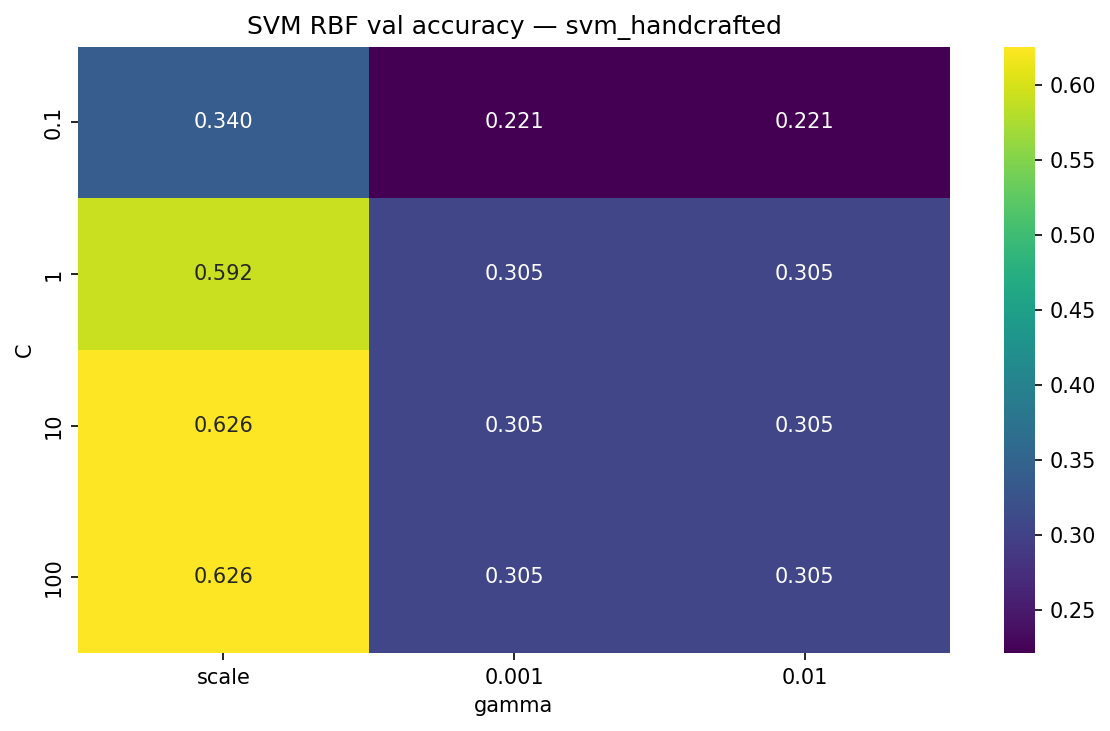

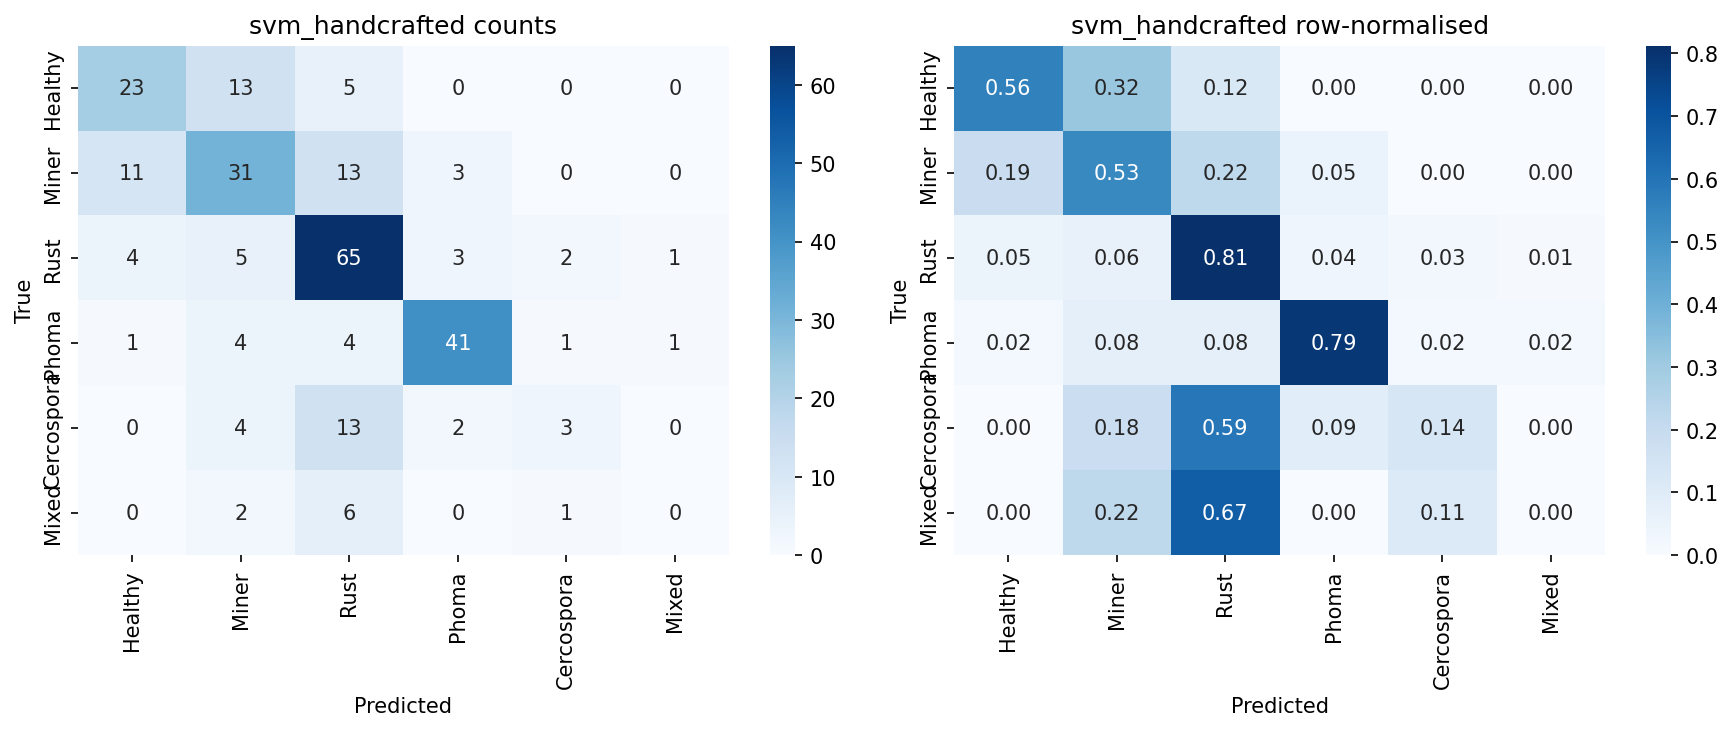

In [ ]:
import importlib
import p1_core
importlib.reload(p1_core)
from p1_core import SVMPipeline

svm_hc = SVMPipeline(
    pack_hc, name="svm_handcrafted",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=False,
    C_grid=[0.1, 1, 10, 100],
    gamma_grid=["scale", 1e-3, 1e-2],
)
svm_hc.run()
record("SVM", "handcrafted", svm_hc)
print(svm_hc.best_params)


[svm_deep] start  train=1222 x 1280  search=25 RBF + 5 linear  proba=True
[svm_deep] ingest  scaling 1222 x 1280  elapsed 0:00
[svm_deep] ingest  done in 0:00  elapsed 0:00
[svm_deep] fit  default RBF C=1 gamma=scale  elapsed 0:00
[svm_deep] fit  done in 0:00  val_acc=0.790  elapsed 0:00
[svm_deep] search  30 configs  elapsed 0:00
[svm_deep] search  1/30  rbf C=0.1 gamma=scale  val_acc=0.660  0:00  remaining ~0:14  elapsed 0:01
[svm_deep] search  2/30  rbf C=0.1 gamma=0.0001  val_acc=0.557  0:01  remaining ~0:14  elapsed 0:01
[svm_deep] search  3/30  rbf C=0.1 gamma=0.001  val_acc=0.641  0:00  remaining ~0:13  elapsed 0:02
[svm_deep] search  4/30  rbf C=0.1 gamma=0.01  val_acc=0.221  0:01  remaining ~0:13  elapsed 0:02
[svm_deep] search  5/30  rbf C=0.1 gamma=0.1  val_acc=0.221  0:00  remaining ~0:12  elapsed 0:03
[svm_deep] search  6/30  rbf C=1 gamma=scale  val_acc=0.790  0:00  remaining ~0:11  elapsed 0:03
[svm_deep] search  7/30  rbf C=1 gamma=0.0001  val_acc=0.729  0:00  remaining

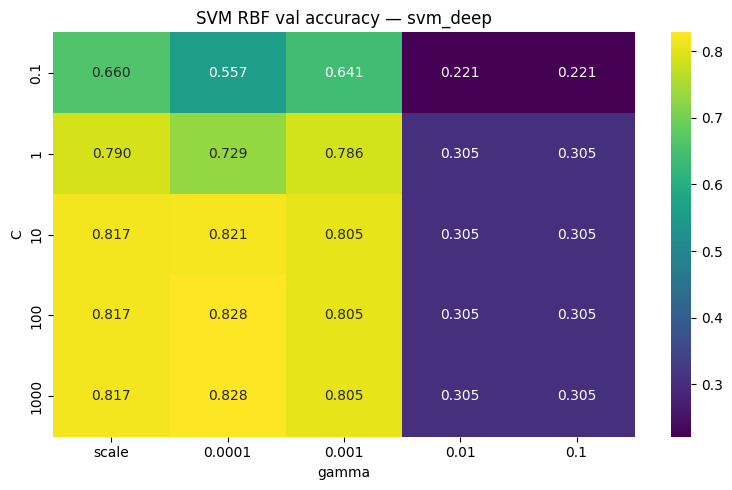

[svm_deep] refit  rbf C=100 gamma=0.0001  proba=True  elapsed 0:12
[svm_deep] refit  done in 0:01  elapsed 0:14


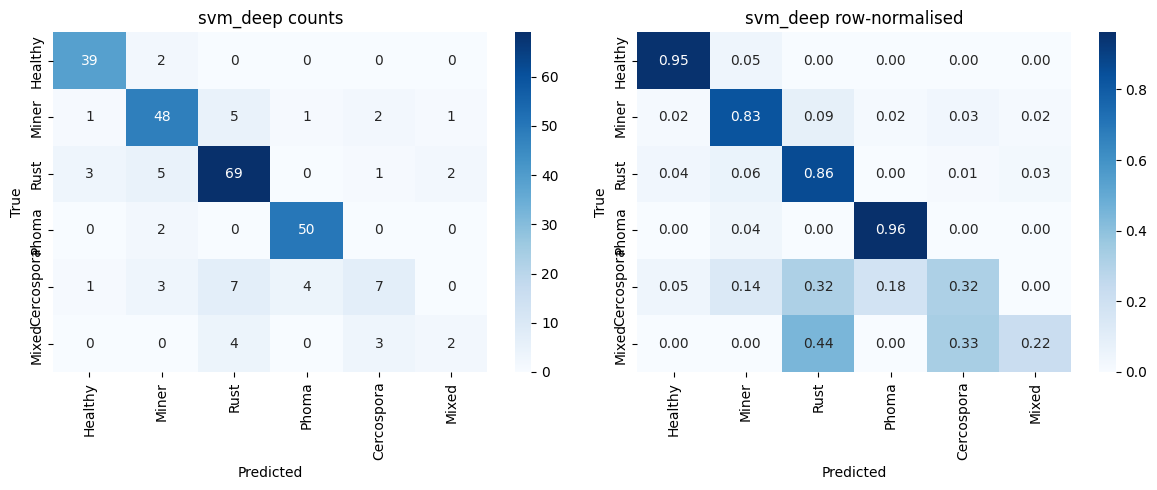

[svm_deep] total 0:14
{'model': 'SVM', 'features': 'deep (frozen EffNet)', 'val_acc': 0.8282442748091603, 'test_acc': 0.8206106870229007, 'macro_f1': 0.6979772903646144, 'best_params': {'kernel': 'rbf', 'C': 100, 'gamma': 0.0001}}
{'kernel': 'rbf', 'C': 100, 'gamma': 0.0001}


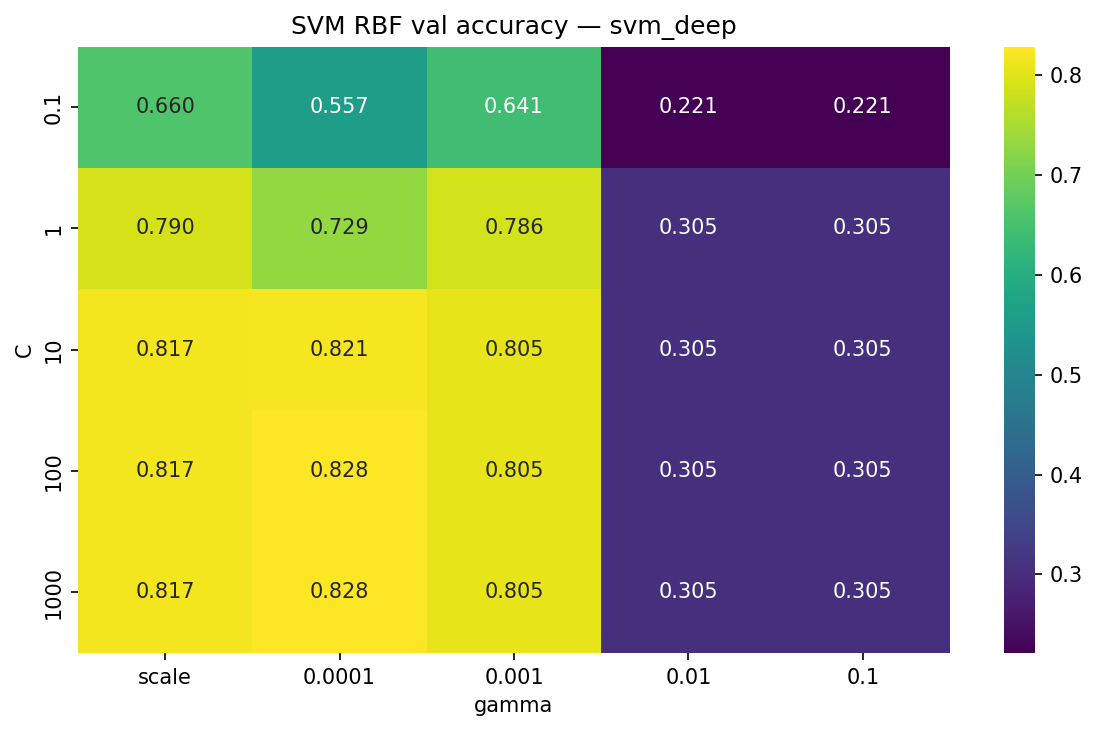

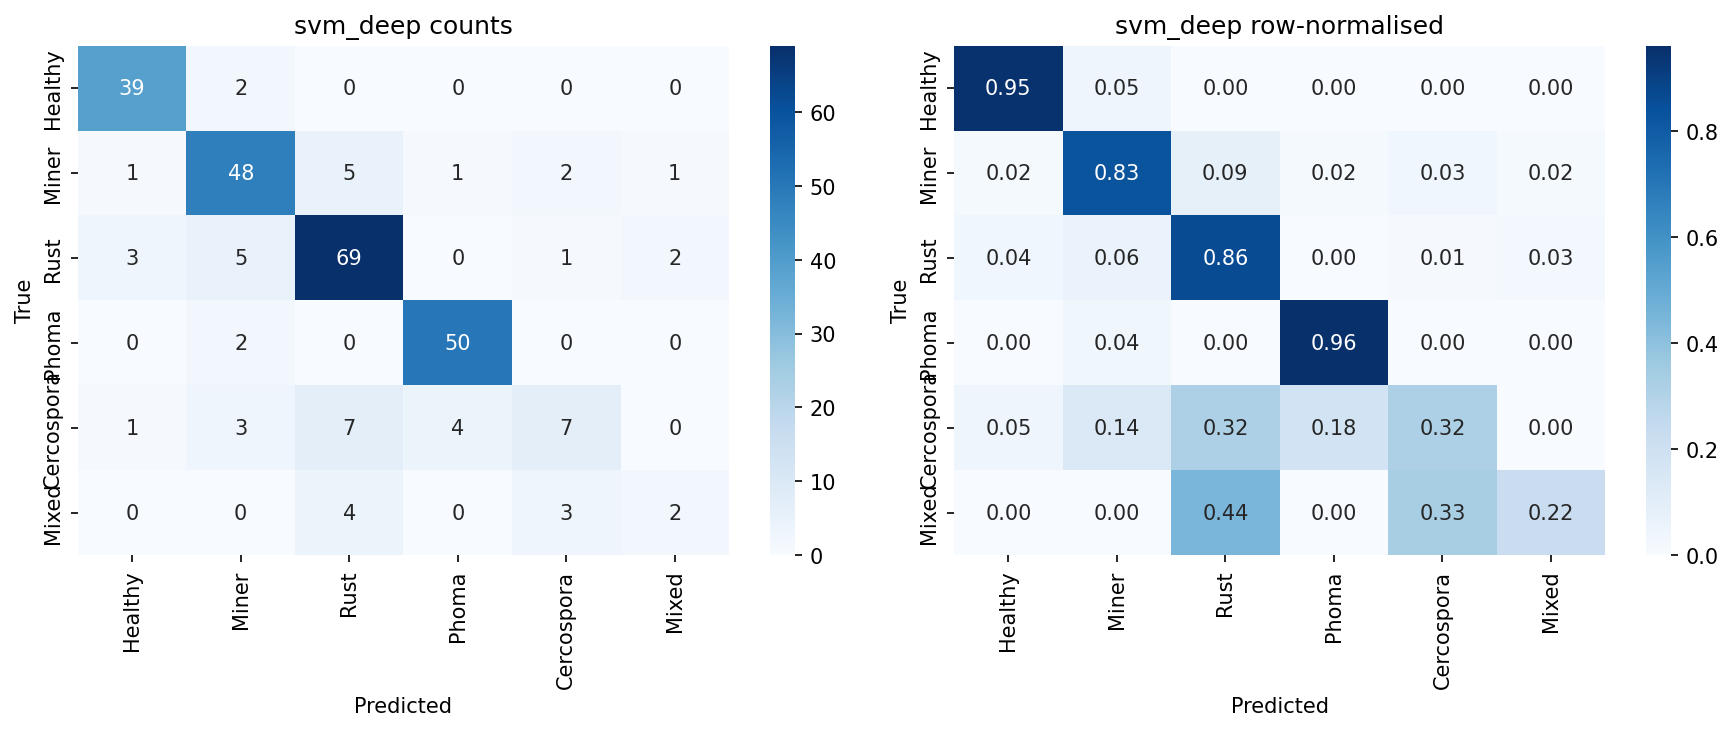

In [19]:
svm_deep = SVMPipeline(
    pack_deep, name="svm_deep",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=True,
)
svm_deep.run()
record("SVM", "deep (frozen EffNet)", svm_deep)
print(svm_deep.best_params)


Best linear SVM on deep features (val): {'kernel': 'linear', 'C': 0.1, 'gamma': None, 'val_acc': 0.8206106870229007}
{'model': 'SVM-linear (ablation)', 'features': 'deep (frozen EffNet)', 'val_acc': 0.8206106870229007, 'test_acc': 0.8053435114503816, 'macro_f1': 0.6837798205773922, 'best_params': {'kernel': 'linear', 'C': 0.1}}


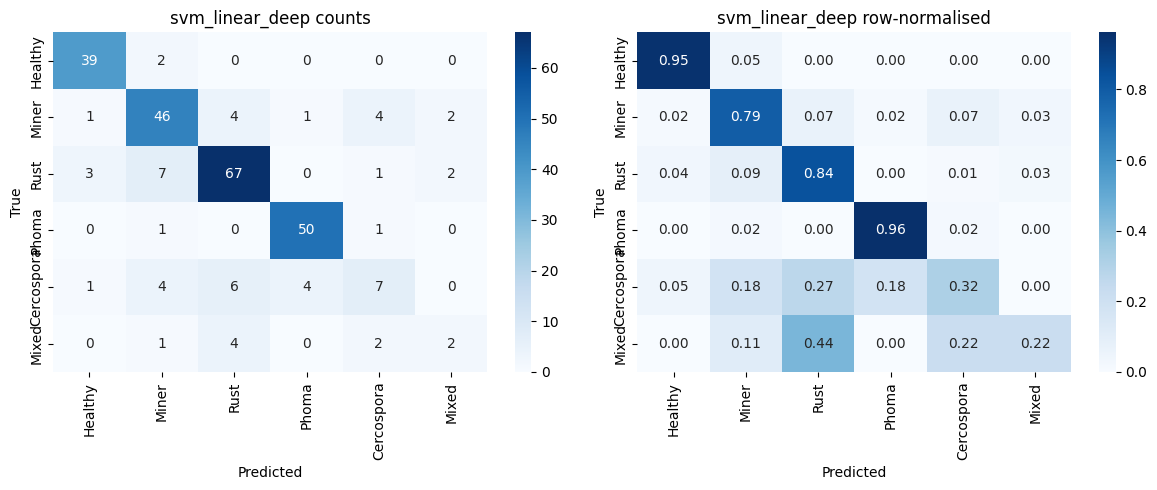

{'acc': 0.8053435114503816,
 'macro_f1': 0.6837798205773922,
 'weighted_f1': 0.7953059986387074,
 'macro_precision': 0.6961188999895739,
 'macro_recall': 0.6806275770689143}

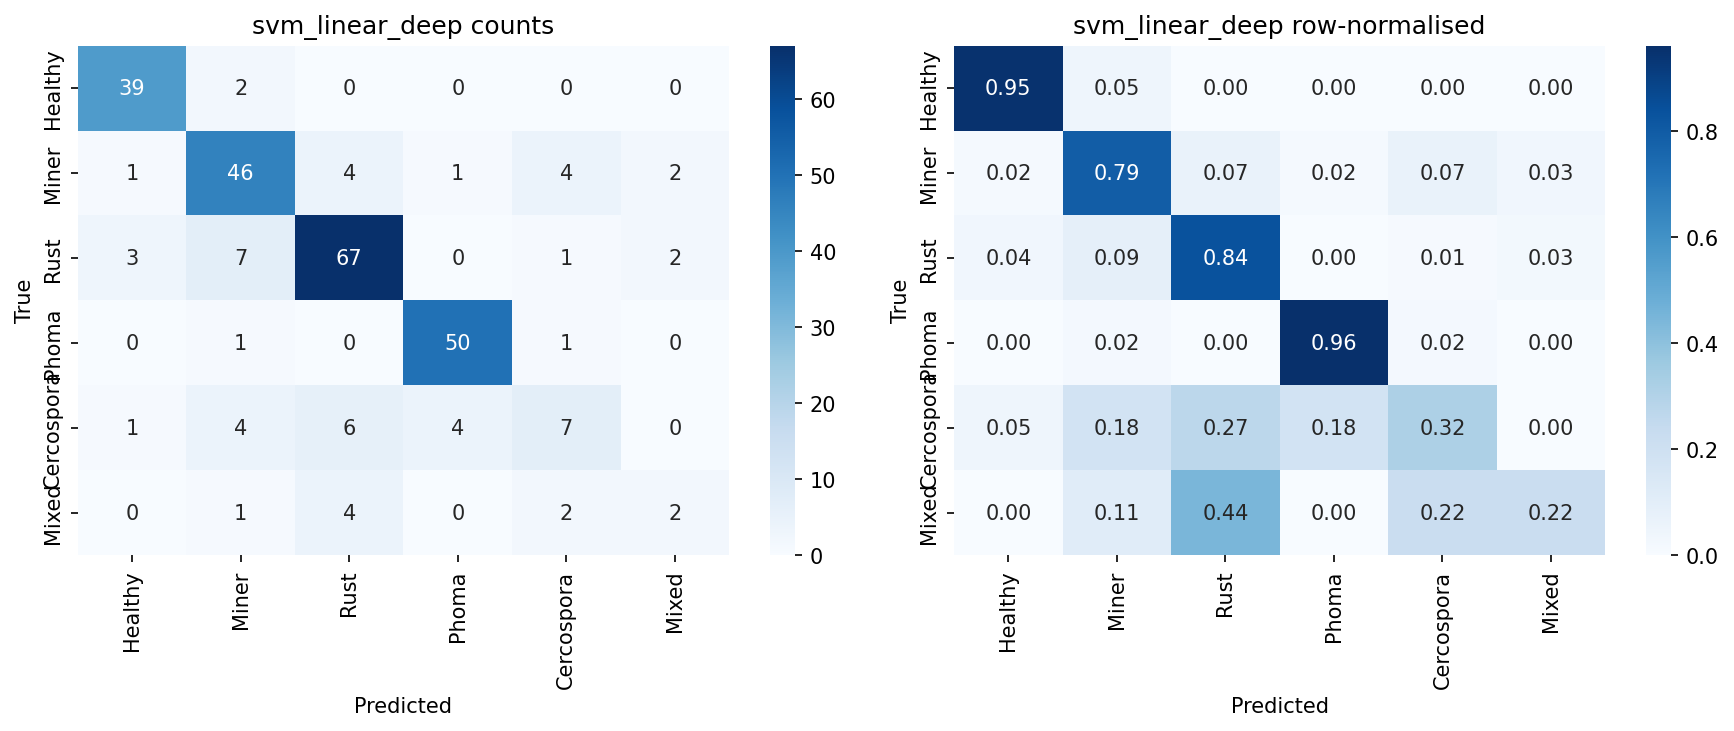

In [20]:
# Linear kernel on deep features is already part of search(); pick the best linear row for a dedicated report.
linear_rows = [r for r in svm_deep.search_table if r["kernel"] == "linear"]
best_linear = max(linear_rows, key=lambda r: r["val_acc"])
print("Best linear SVM on deep features (val):", best_linear)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

scaled_deep, _ = scale_pack(pack_deep)
lin = SVC(kernel="linear", C=best_linear["C"], class_weight="balanced")
lin.fit(scaled_deep.X_train, scaled_deep.y_train)
pred_lin = lin.predict(scaled_deep.X_test)
pred_lin_val = lin.predict(scaled_deep.X_val)
record(
    "SVM-linear (ablation)",
    "deep (frozen EffNet)",
    val_acc=float(accuracy_score(scaled_deep.y_val, pred_lin_val)),
    test_acc=float(accuracy_score(scaled_deep.y_test, pred_lin)),
    macro_f1=float(f1_score(scaled_deep.y_test, pred_lin, average="macro", zero_division=0)),
    best_params={"kernel": "linear", "C": best_linear["C"]},
)
svm_deep.report(scaled_deep.y_test, pred_lin, "svm_linear_deep")


Optional PCA pack for SVM. Same loop, smaller vectors. Useful if the 1280-d RBF grid is slow.


{'model': 'SVM', 'features': 'deep PCA-256', 'val_acc': 0.7977099236641222, 'test_acc': 0.7900763358778626, 'macro_f1': 0.6090600199195503, 'best_params': {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}}


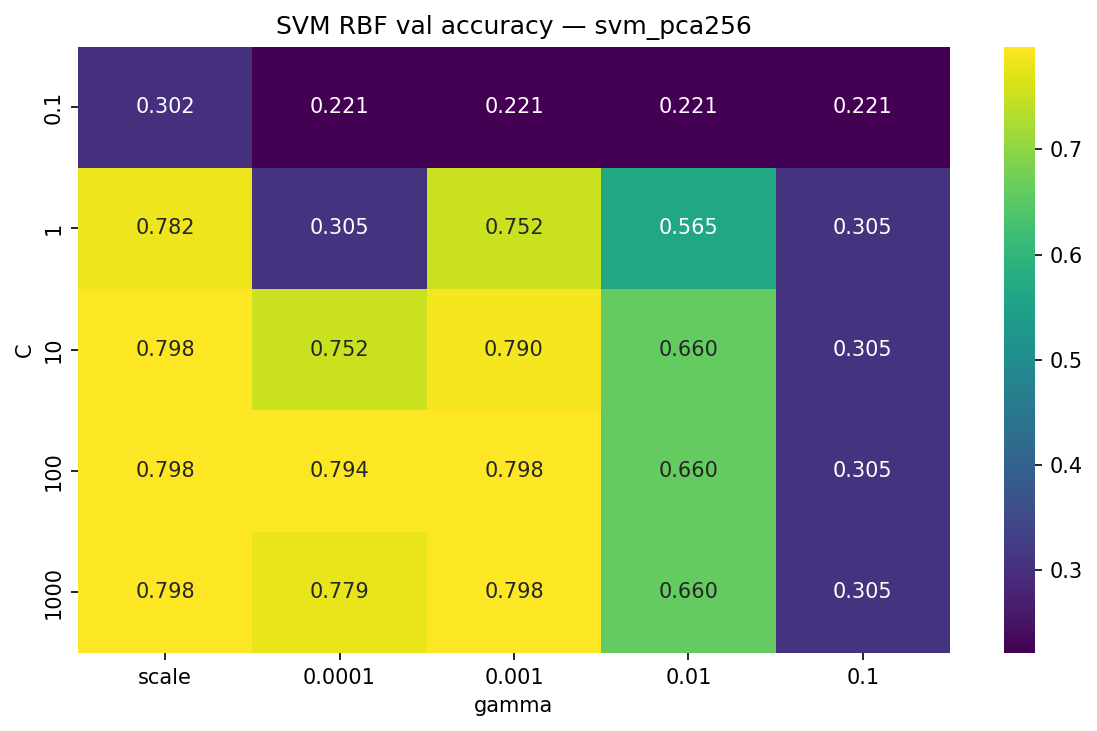

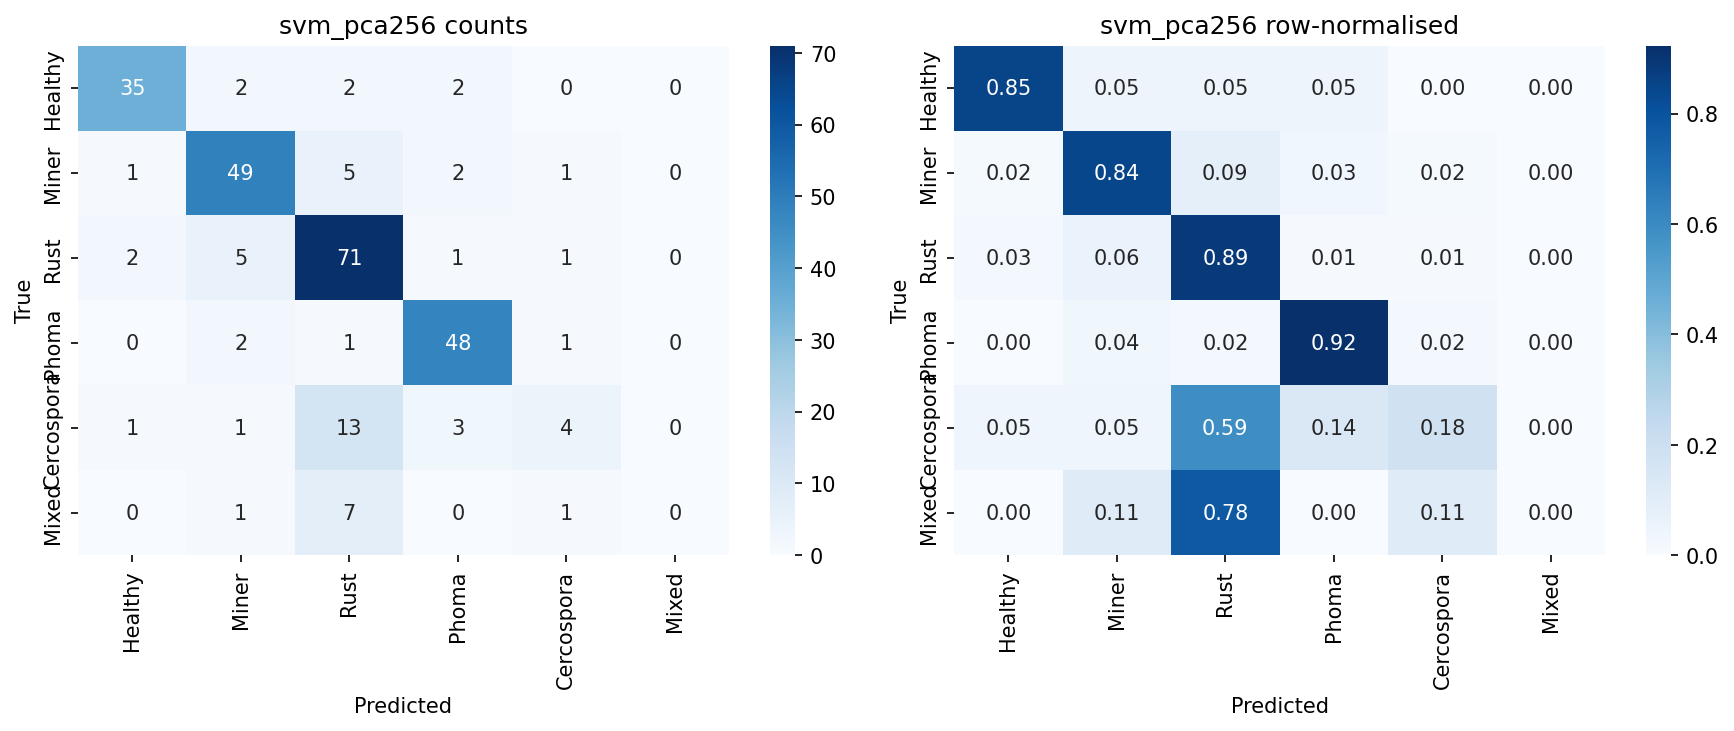

In [15]:
svm_pca = SVMPipeline(
    pack_pca, name="svm_pca256",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=False,
)
svm_pca.run()
record("SVM", "deep PCA-256", svm_pca)


### Model 1 literature note

Margin classifiers on frozen CNN embeddings are a standard transfer-learning probe. We are not copying Esgario's protocol here: they fine-tune ResNet-50 on pixels. The SVM numbers answer a different question: how much of the disease signal is already in ImageNet features.


## 9. Model 2 — EfficientNet-B0, full grading loop

Personalized ingest: raw 224×224 RGB. MixUp plus flips. Phase 1 trains the head with a frozen backbone. Phase 2 opens the last layers at a lower learning rate. Early stopping watches validation loss. Test is scored once after search.


Epoch 1/12


2026-08-27 10:39:27.550931: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-08-27 10:39:27.576361: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.025630747s
Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn

2026-08-27 10:39:28.768448: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-08-27 10:39:28.836213: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.067979043s
Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn

2026-08-27 10:39:29.258709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 10:39:29.454944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 10:39:29.642714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...


69/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6575 - loss: 1.3768


73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6585 - loss: 1.3753


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6596 - loss: 1.3739


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6792 - loss: 1.3498 - val_accuracy: 0.7634 - val_loss: 0.8313 - learning_rate: 2.5000e-06


{'model': 'EfficientNet-B0', 'features': 'raw images', 'val_acc': 0.7824427480916031, 'test_acc': 0.767175572519084, 'macro_f1': 0.6517284641397751, 'best_params': {'lr': 0.0001, 'dropout': 0.3, 'unfreeze': 20}}
EffNet best params: {'lr': 0.0001, 'dropout': 0.3, 'unfreeze': 20}


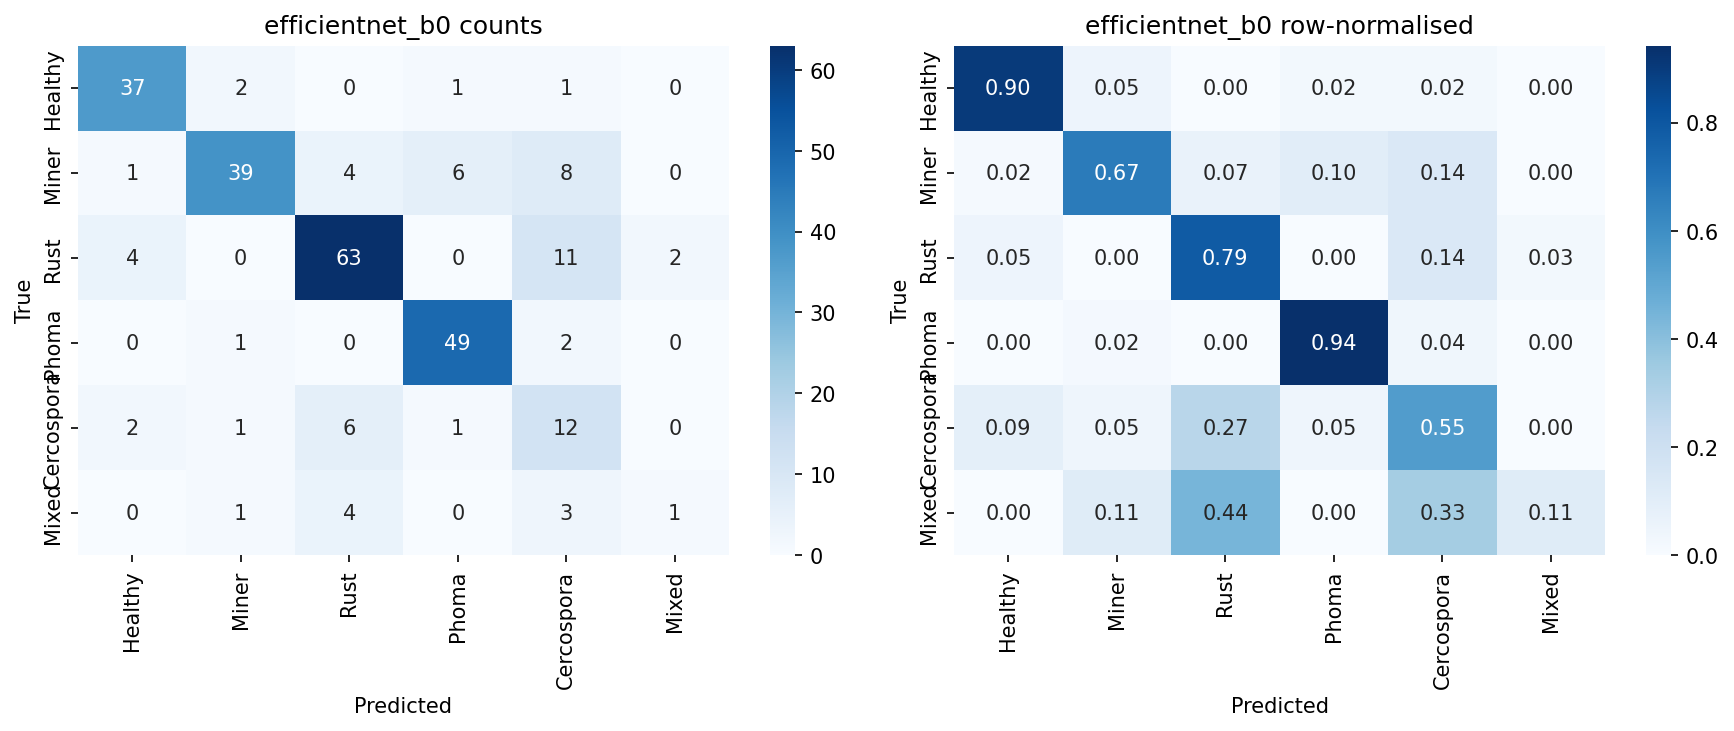

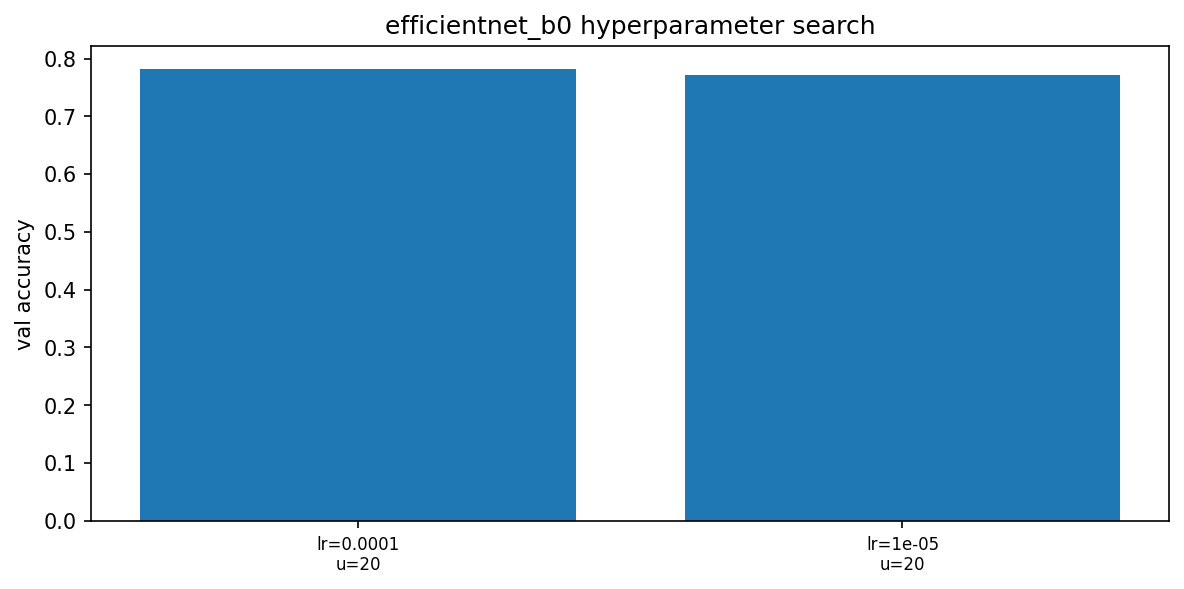

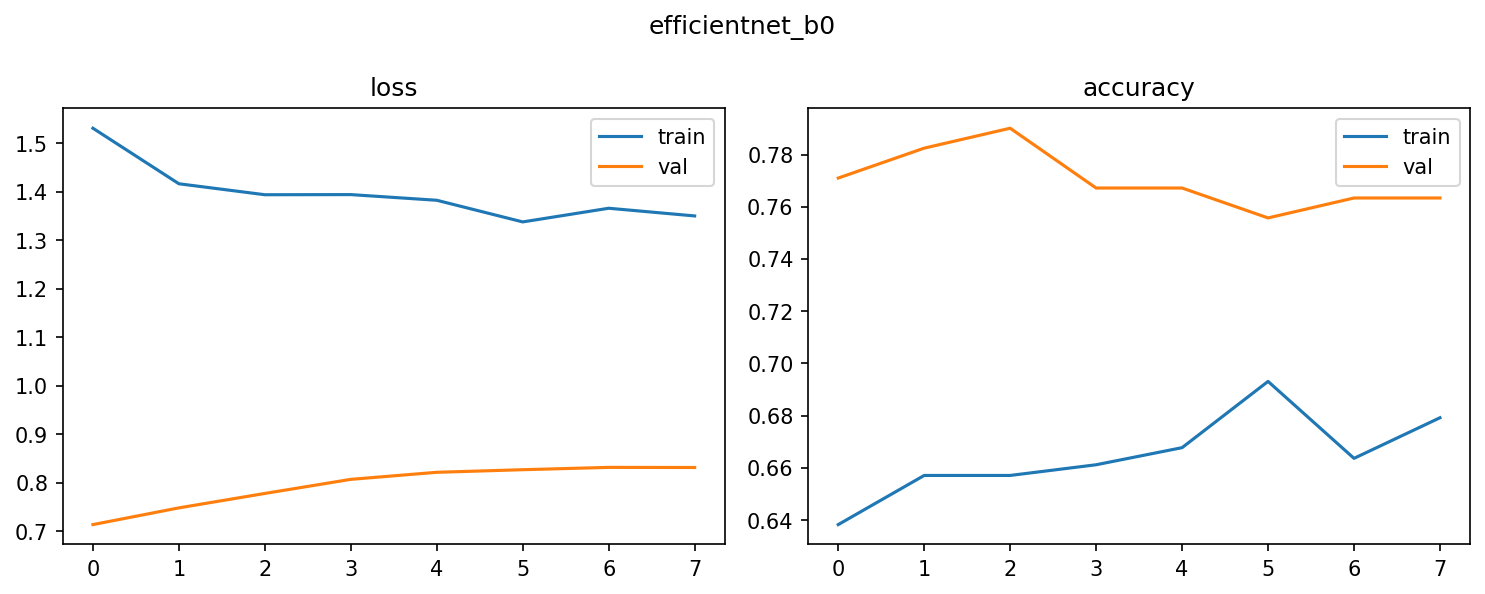

In [16]:
# Keep the default grid small so the notebook can finish. Widen it if you have more GPU time.
effnet = EfficientNetPipeline(
    dataset, split,
    name="efficientnet_b0",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=True,
    epochs_head=12,
    epochs_ft=20,
    batch_size=16,
    search_grid=[
        {"lr": 1e-4, "dropout": 0.3, "unfreeze": 20},
        {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20},
    ],
)
effnet.run()
record("EfficientNet-B0", "raw images", effnet)
print("EffNet best params:", effnet.best_params)


## 10. Extras (criterion i)


### 10.1 XGBoost on the same cached features


{'model': 'XGBoost', 'features': 'handcrafted', 'val_acc': 0.7786259541984732, 'test_acc': 0.7824427480916031, 'macro_f1': 0.6004552323737383, 'best_params': {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}}


{'model': 'XGBoost', 'features': 'deep (frozen EffNet)', 'val_acc': 0.8320610687022901, 'test_acc': 0.816793893129771, 'macro_f1': 0.6800370443771383, 'best_params': {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}}


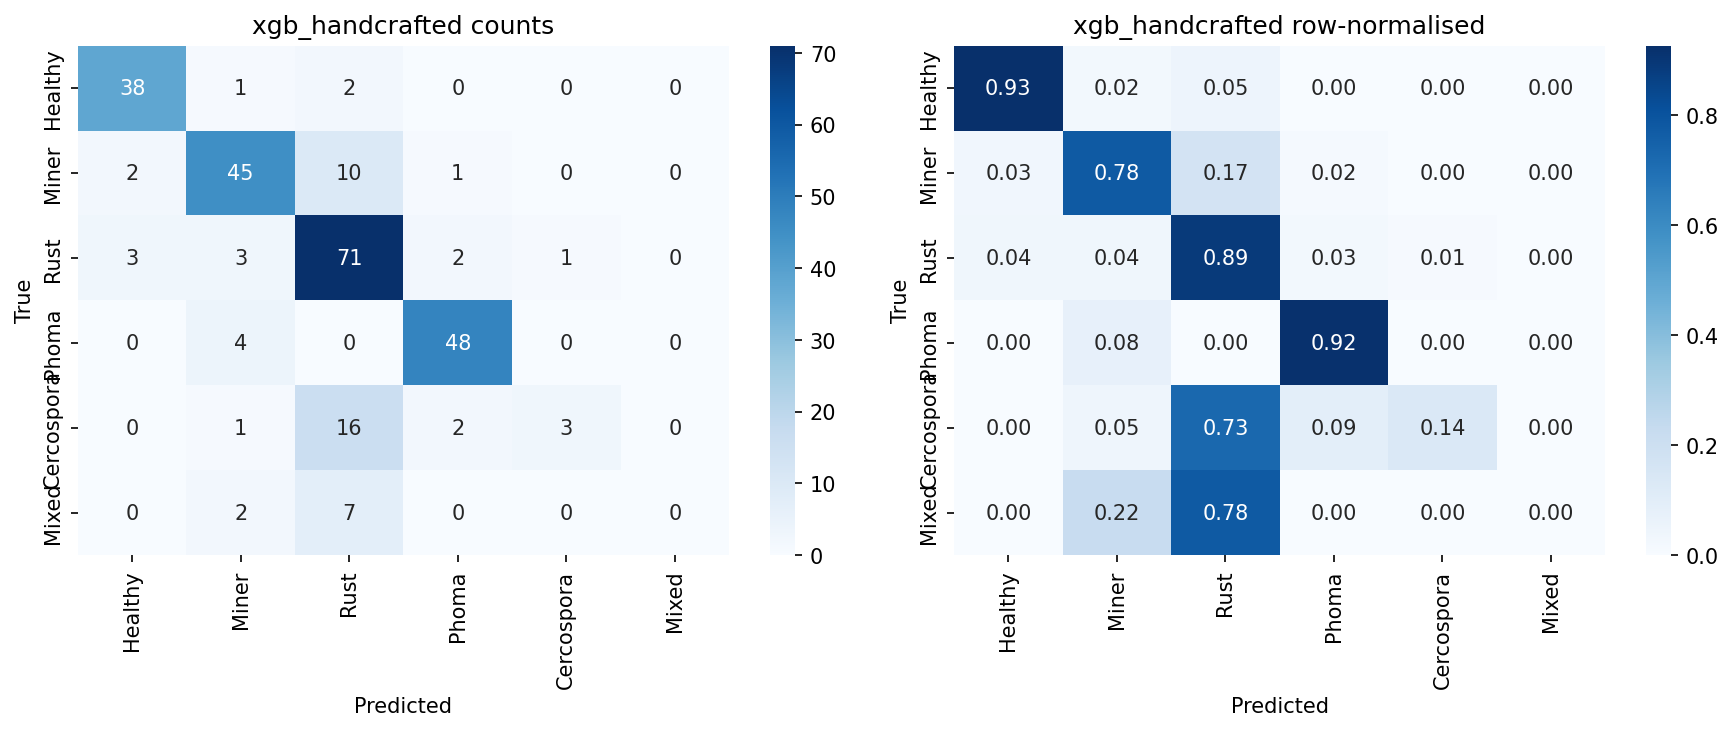

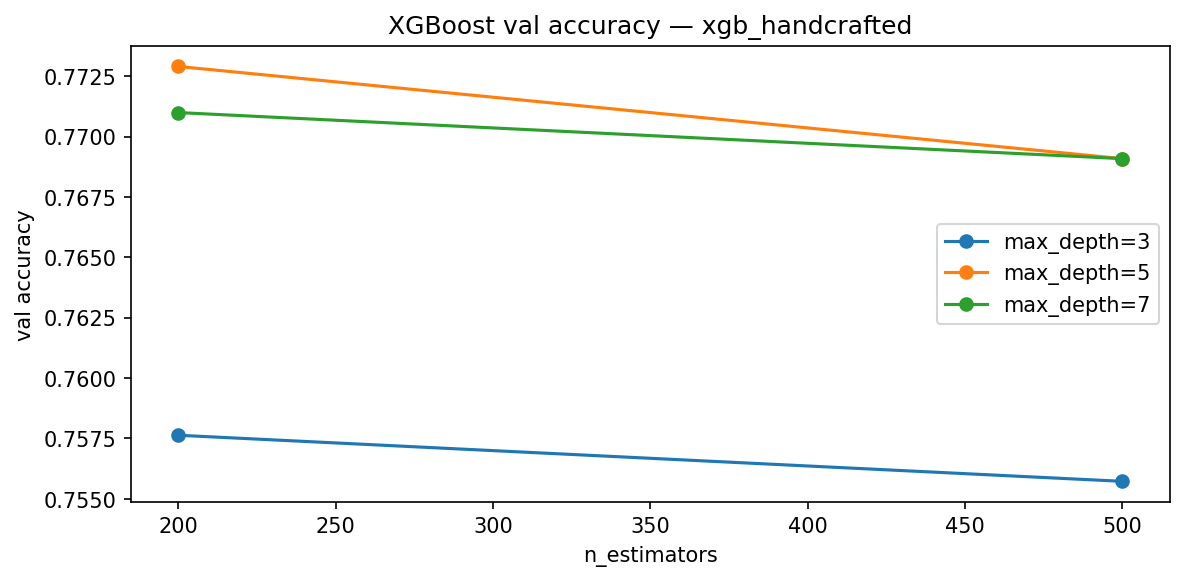

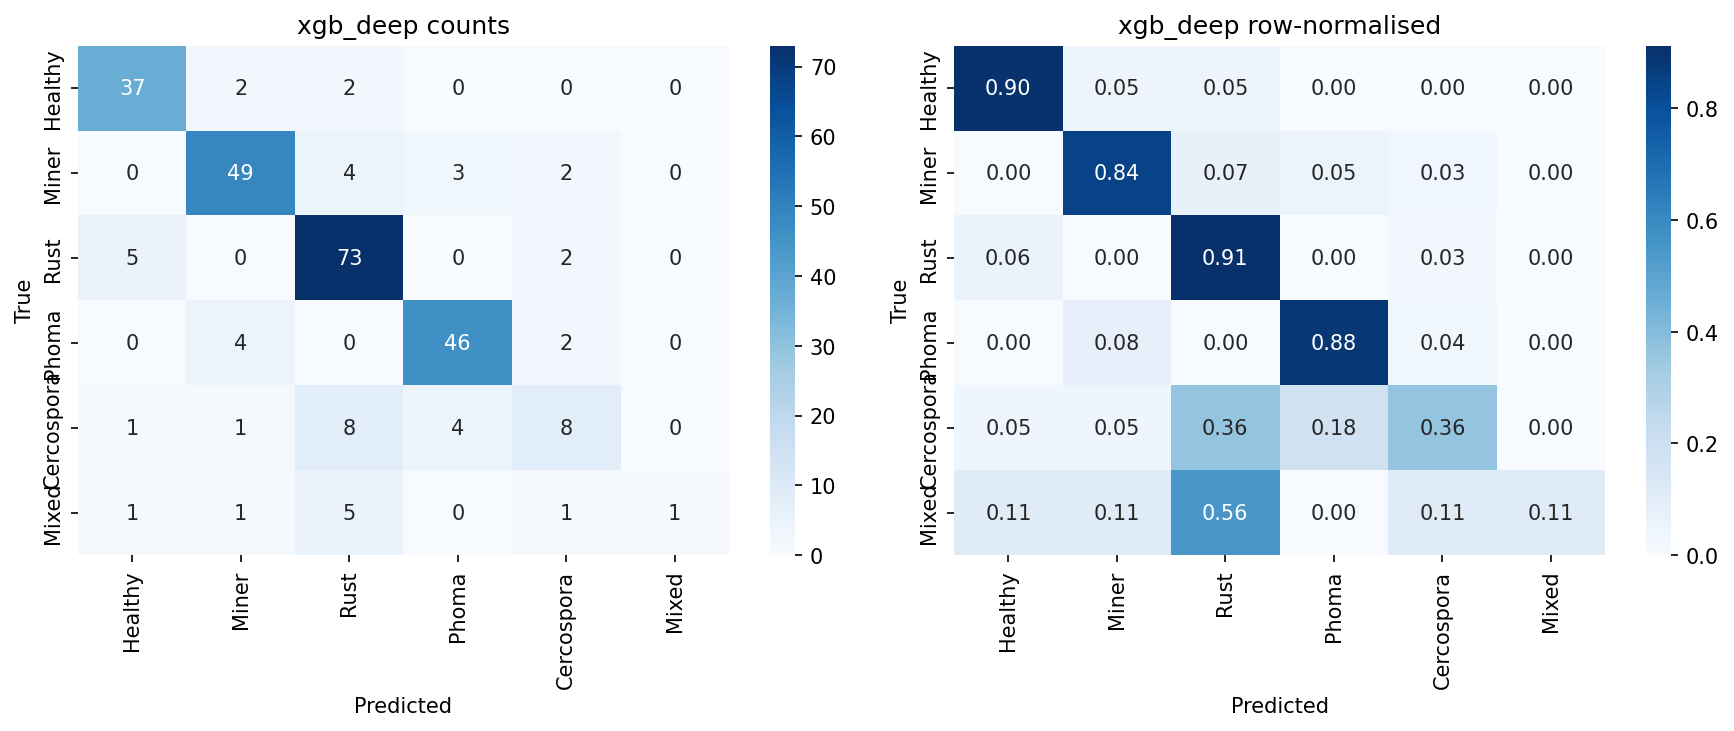

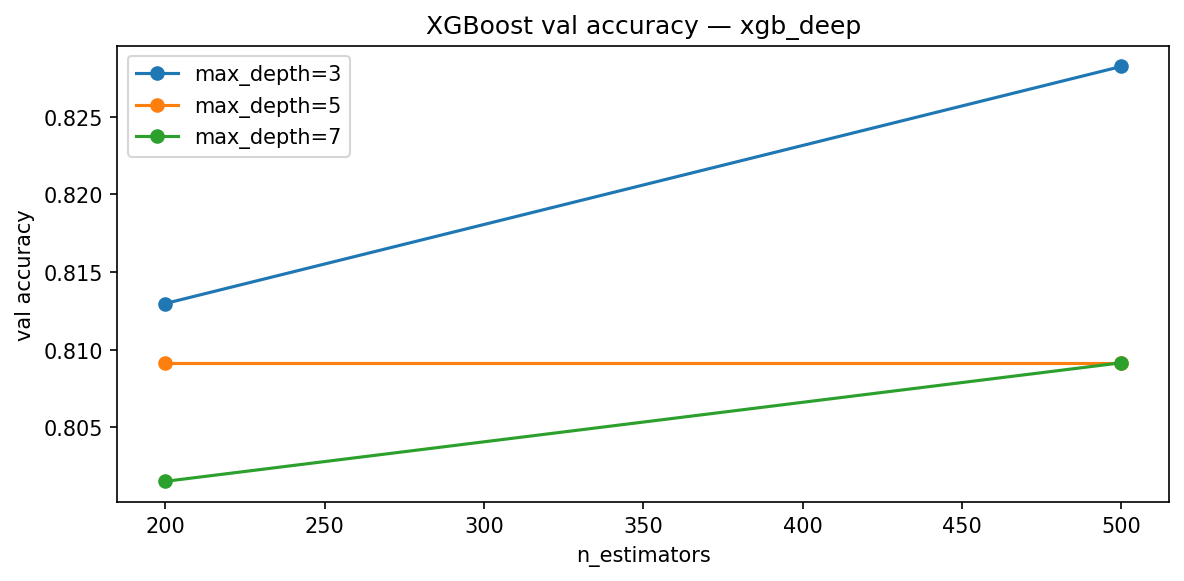

In [17]:
xgb_hc = XGBoostPipeline(
    pack_hc, name="xgb_handcrafted",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
)
xgb_hc.run()
record("XGBoost", "handcrafted", xgb_hc)

xgb_deep = XGBoostPipeline(
    pack_deep, name="xgb_deep",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
)
xgb_deep.run()
record("XGBoost", "deep (frozen EffNet)", xgb_deep)


### 10.2 ResNet-50 (third method, same protocol as EfficientNet)



       0/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step


   16384/94765736 ━━━━━━━━━━━━━━━━━━━━ 10:43 7us/step


   32768/94765736 ━━━━━━━━━━━━━━━━━━━━ 12:37 8us/step


   40960/94765736 ━━━━━━━━━━━━━━━━━━━━ 18:19 12us/step


   65536/94765736 ━━━━━━━━━━━━━━━━━━━━ 14:06 9us/step 

...


73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9955 - loss: 0.1050


75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9955 - loss: 0.1050


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9954 - loss: 0.1051


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9926 - loss: 0.1071 - val_accuracy: 0.8359 - val_loss: 0.5872 - learning_rate: 5.0000e-06


{'model': 'ResNet-50', 'features': 'raw images', 'val_acc': 0.8206106870229007, 'test_acc': 0.8091603053435115, 'macro_f1': 0.6774479971180614, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}}


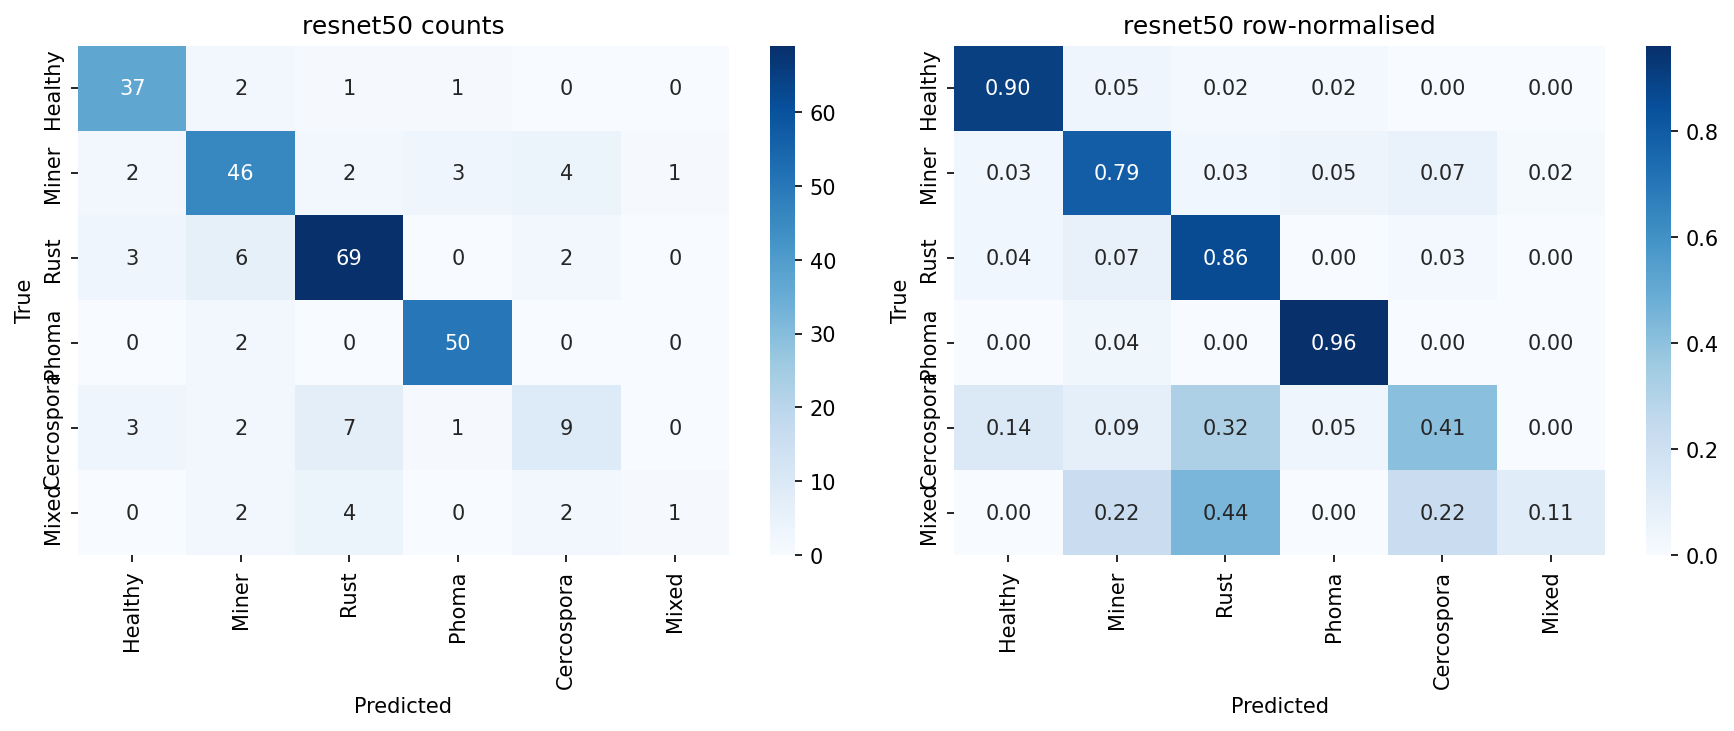

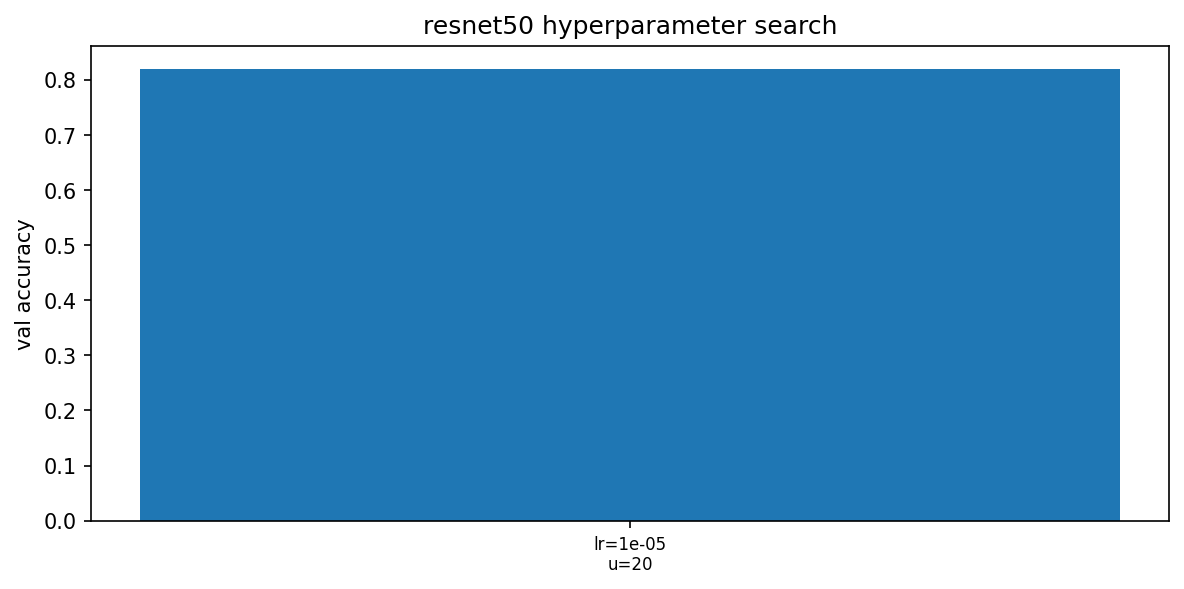

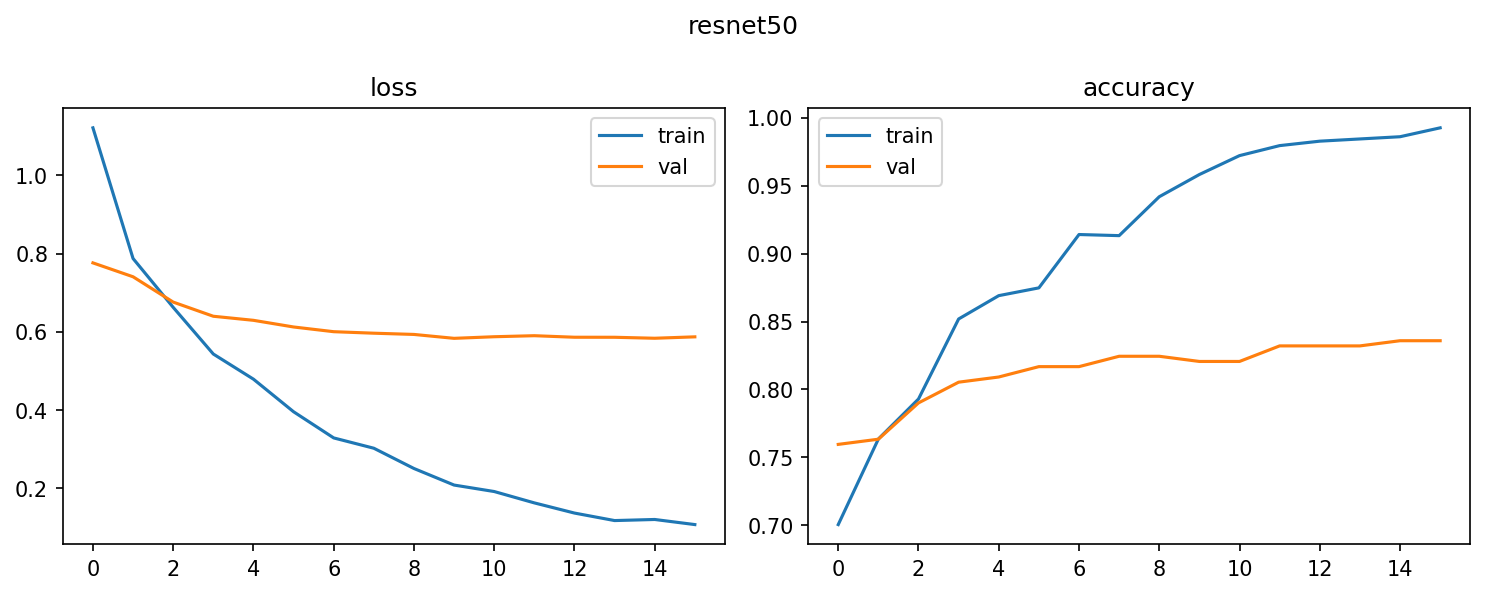

In [18]:
resnet = ResNetPipeline(
    dataset, split,
    name="resnet50",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=True,
    epochs_head=10,
    epochs_ft=16,
    batch_size=16,
    search_grid=[
        {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20},
    ],
)
resnet.run()
record("ResNet-50", "raw images", resnet)


### 10.3 MixUp on/off ablation on EfficientNet (short run)


Epoch 1/8



 1/77 ━━━━━━━━━━━━━━━━━━━━ 11:32 9s/step - accuracy: 0.3750 - loss: 1.4162


 2/77 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.3750 - loss: 1.6837


 3/77 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.3403 - loss: 1.8391


 7/77 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2726 - loss: 2.0312  

...


69/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7578 - loss: 0.7502


73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7588 - loss: 0.7526


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7596 - loss: 0.7552


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7733 - loss: 0.8133 - val_accuracy: 0.7710 - val_loss: 0.6913 - learning_rate: 2.5000e-06


{'model': 'EfficientNet-B0 (no MixUp)', 'features': 'raw images', 'val_acc': 0.7862595419847328, 'test_acc': 0.7786259541984732, 'macro_f1': 0.6722220346050177, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20, 'mixup': False}}


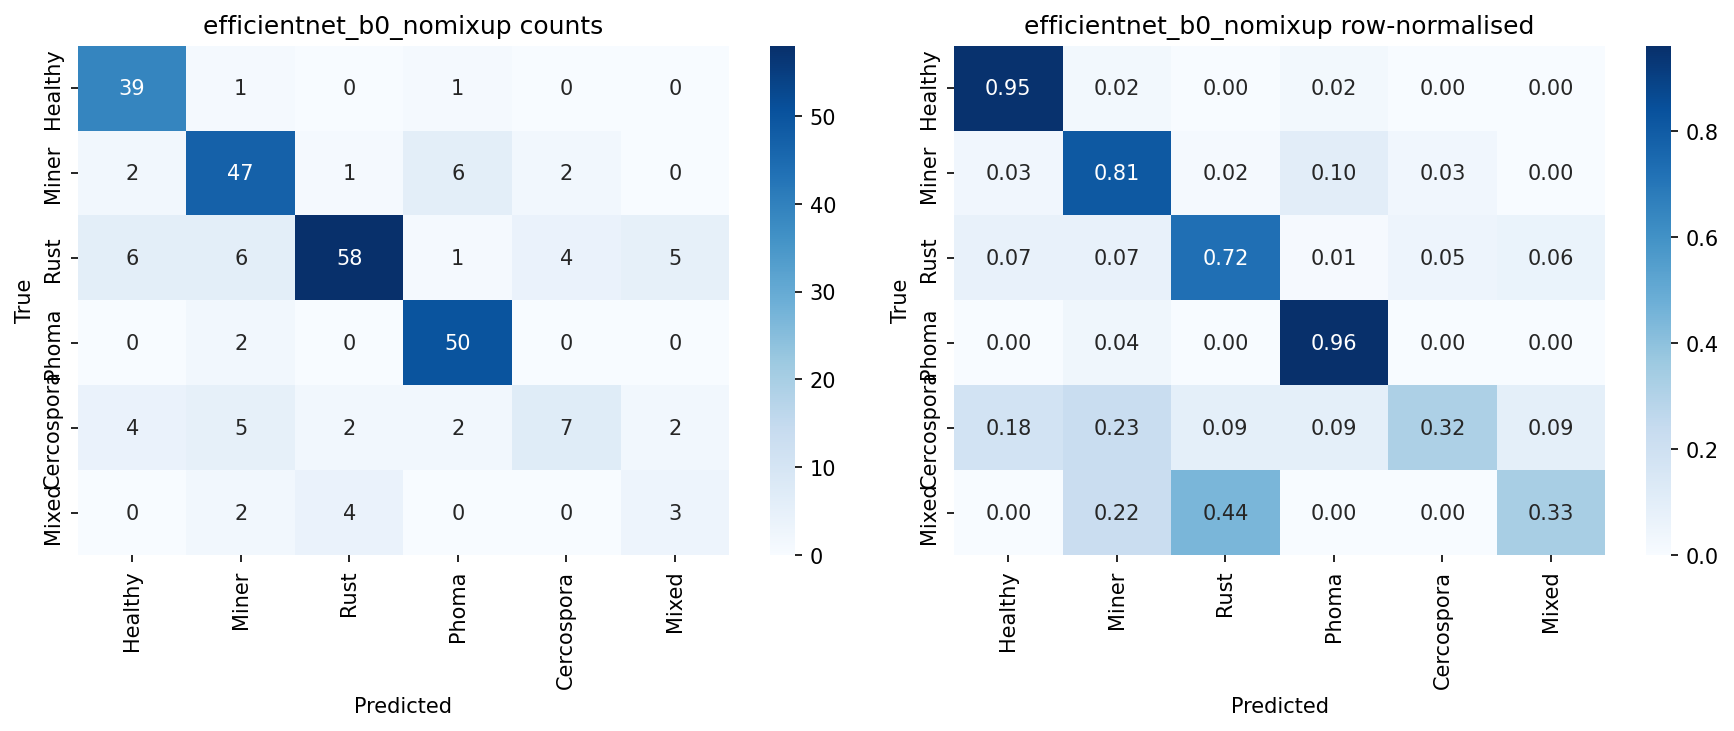

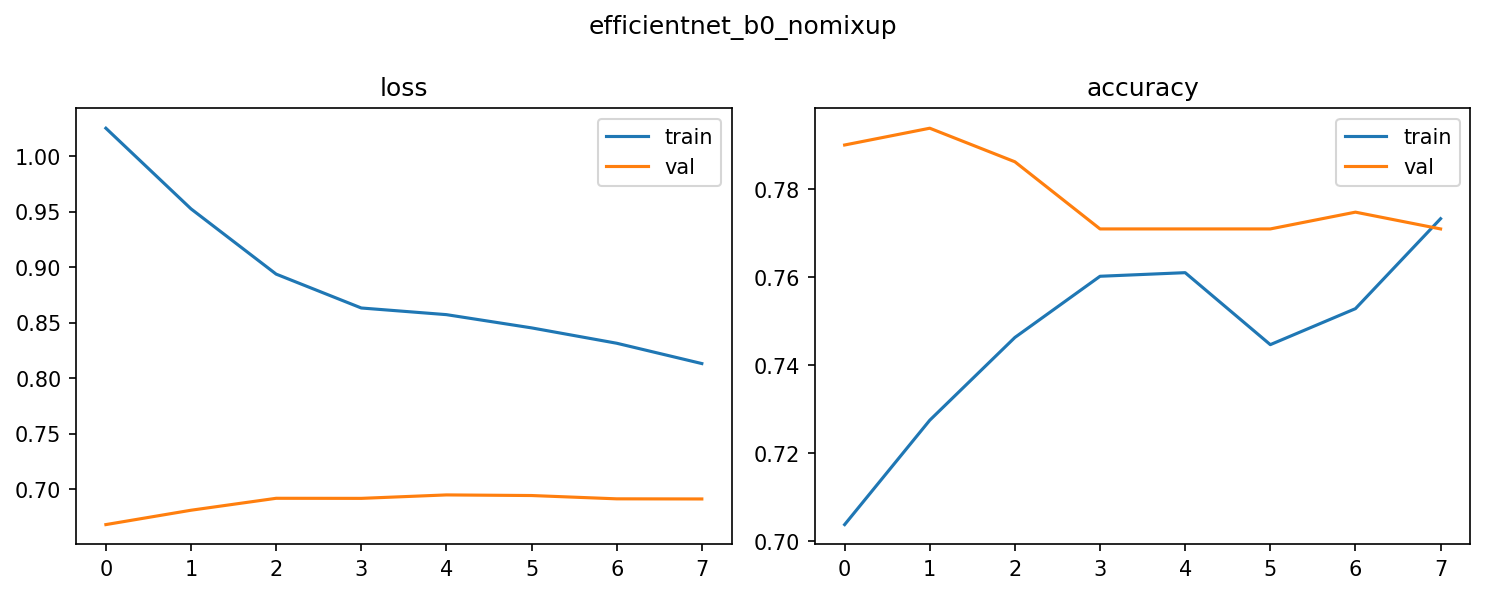

In [19]:
effnet_nomix = EfficientNetPipeline(
    dataset, split,
    name="efficientnet_b0_nomixup",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=False,
    epochs_head=8,
    epochs_ft=12,
    batch_size=16,
    search_grid=[{"lr": 1e-5, "dropout": 0.3, "unfreeze": 20}],
)
# Skip a second full search: fit + refit is enough for the ablation row.
effnet_nomix.ingest()
effnet_nomix.fit()
effnet_nomix.best_params = {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20, "mixup": False}
effnet_nomix.refit()
effnet_nomix.test_metrics = effnet_nomix.report(
    effnet_nomix.y_true_test, effnet_nomix.y_pred_test, effnet_nomix.name
)
record("EfficientNet-B0 (no MixUp)", "raw images", effnet_nomix)


### 10.4 Probability ensemble


Ensemble SVM-deep + EffNet: {'acc': 0.8091603053435115, 'macro_f1': 0.6476925404696792, 'weighted_f1': 0.7945779890800174, 'macro_precision': 0.6388762721762782, 'macro_recall': 0.6580534513145951}


{'model': 'Ensemble', 'features': 'SVM-deep + EffNet', 'val_acc': None, 'test_acc': 0.8091603053435115, 'macro_f1': 0.6476925404696792, 'best_params': {'combine': 'mean_proba'}}
Ensemble + ResNet: {'acc': 0.8435114503816794, 'macro_f1': 0.7107452193852272, 'weighted_f1': 0.8292555900706399, 'macro_precision': 0.8428764771902025, 'macro_recall': 0.7019616628426552}
{'model': 'Ensemble', 'features': 'SVM-deep + EffNet + ResNet', 'val_acc': None, 'test_acc': 0.8435114503816794, 'macro_f1': 0.7107452193852272, 'best_params': {'combine': 'mean_proba'}}


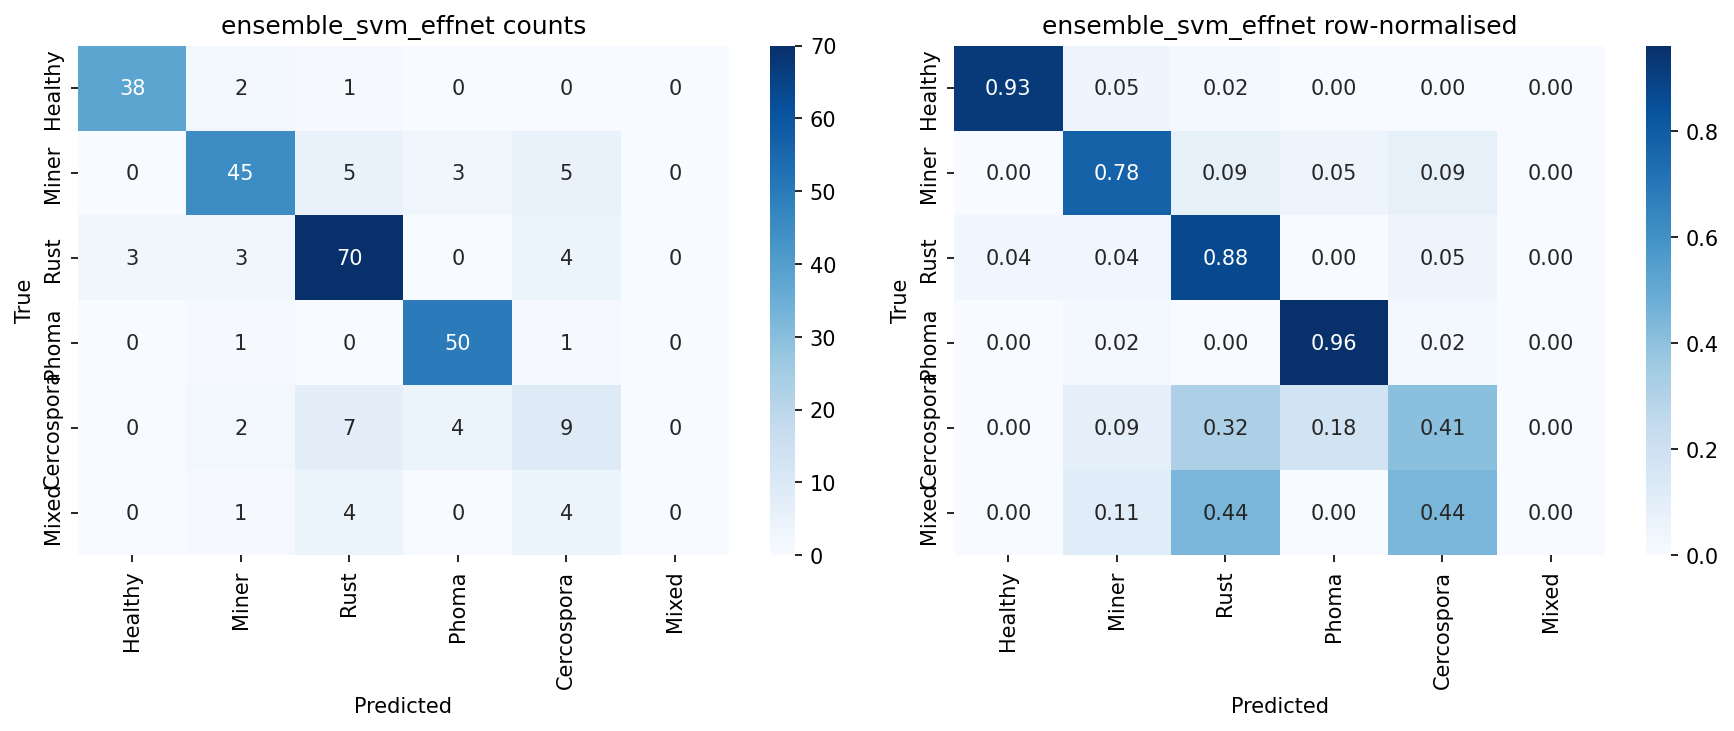

In [20]:
from sklearn.metrics import accuracy_score, f1_score

proba_svm = svm_deep.proba_test
proba_eff = effnet.proba_test
proba_ens = ensemble_average(proba_svm, proba_eff)
y_ens = np.argmax(proba_ens, axis=1)
y_test = svm_deep.y_true_test
ens_metrics = classification_metrics(y_test, y_ens)
print("Ensemble SVM-deep + EffNet:", ens_metrics)
svm_deep.report(y_test, y_ens, "ensemble_svm_effnet")
record(
    "Ensemble",
    "SVM-deep + EffNet",
    val_acc=None,
    test_acc=ens_metrics["acc"],
    macro_f1=ens_metrics["macro_f1"],
    best_params={"combine": "mean_proba"},
)

if resnet.proba_test is not None:
    proba_3 = ensemble_average(proba_svm, proba_eff, resnet.proba_test)
    y3 = np.argmax(proba_3, axis=1)
    m3 = classification_metrics(y_test, y3)
    print("Ensemble + ResNet:", m3)
    record(
        "Ensemble",
        "SVM-deep + EffNet + ResNet",
        val_acc=None,
        test_acc=m3["acc"],
        macro_f1=m3["macro_f1"],
        best_params={"combine": "mean_proba"},
    )


### 10.5 Class-5 residual rule

Official task stays 6-class. Extra variant: a multi-label probe on the four binary disease columns. Predict Mixed if two heads fire above τ, or if the 6-class top-1 vs top-2 gap is below δ. τ and δ are chosen on validation only.


Locked tau, delta: 0.6 0.15
Residual rule val: {'acc': 0.6793893129770993, 'macro_f1': 0.6132519141270345, 'weighted_f1': 0.731877677011727, 'macro_precision': 0.7430409008954703, 'macro_recall': 0.6401433751044768}
Residual rule test: {'acc': 0.6374045801526718, 'macro_f1': 0.5983272645591297, 'weighted_f1': 0.7071811338623702, 'macro_precision': 0.7294799666502266, 'macro_recall': 0.6157341636262997}


{'model': 'SVM-deep + residual rule', 'features': 'deep (frozen EffNet)', 'val_acc': 0.6793893129770993, 'test_acc': 0.6374045801526718, 'macro_f1': 0.5983272645591297, 'best_params': {'tau': 0.6, 'delta': 0.15}}


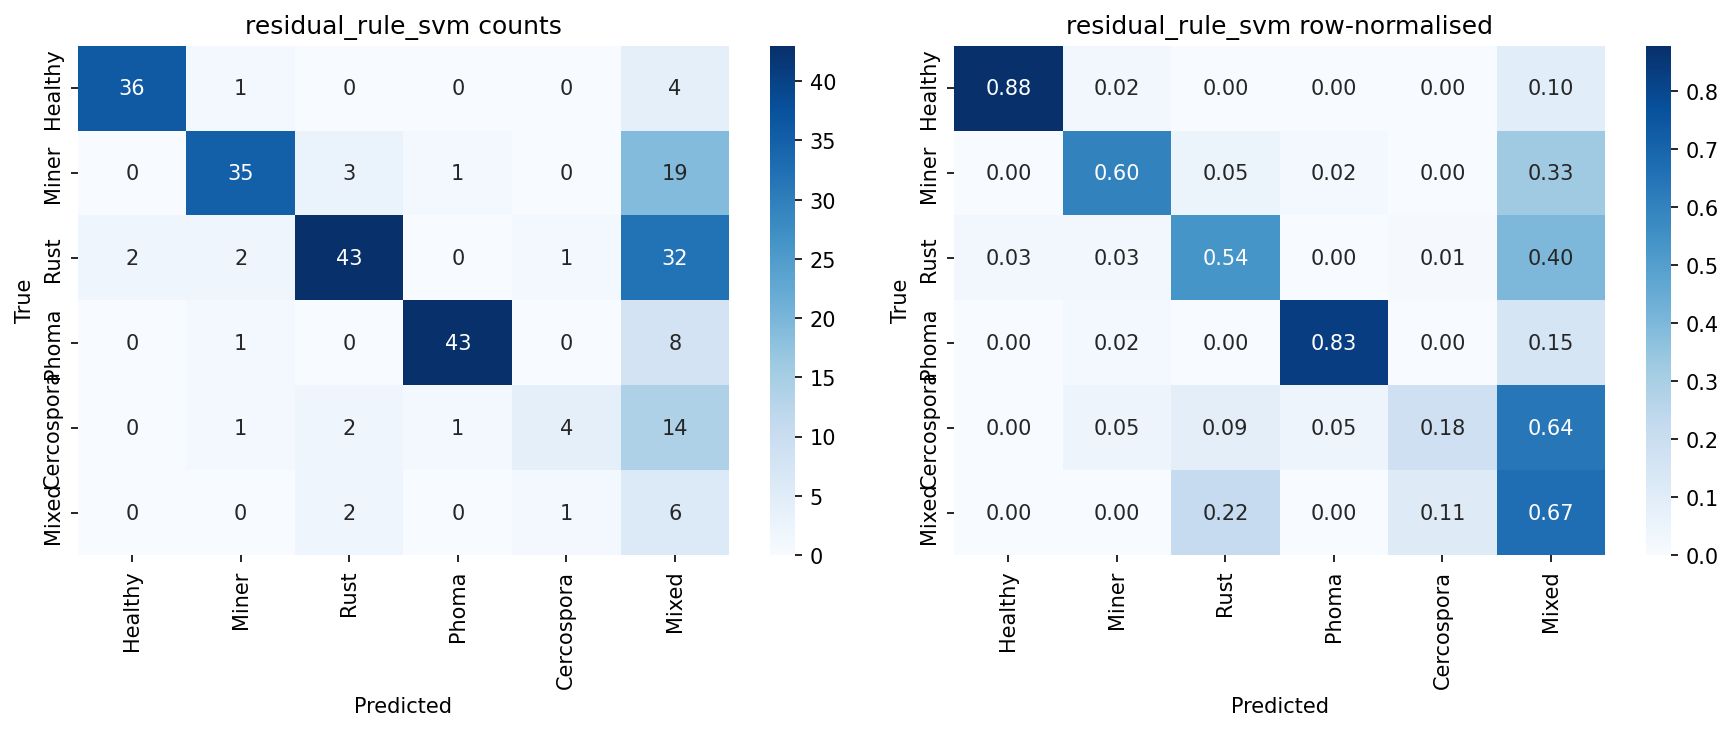

In [21]:
from sklearn.preprocessing import StandardScaler

disease_cols = ["miner", "rust", "phoma", "cercospora"]
Y_all = df[disease_cols].values.astype(np.int32)
Y_train = Y_all[split.train_idx]
Y_val = Y_all[split.val_idx]
Y_test = Y_all[split.test_idx]

# Probe on scaled frozen embeddings (already extracted, no extra CNN).
sc = StandardScaler()
Ztr = sc.fit_transform(pack_deep.X_train)
Zva = sc.transform(pack_deep.X_val)
Zte = sc.transform(pack_deep.X_test)

disease_val = fit_disease_probe(Ztr, Y_train, Zva)
disease_test = fit_disease_probe(Ztr, Y_train, Zte)

proba_val = svm_deep.model.predict_proba(svm_deep.scaled.X_val)
proba_test = svm_deep.proba_test

rule = ResidualMixedRule()
tau, delta = rule.search(pack_deep.y_val, proba_val, disease_val)
print("Locked tau, delta:", tau, delta)

y_rule_val = rule.predict(proba_val, disease_val)
y_rule_test = rule.predict(proba_test, disease_test)
rule_val = classification_metrics(pack_deep.y_val, y_rule_val)
rule_test = classification_metrics(pack_deep.y_test, y_rule_test)
print("Residual rule val:", rule_val)
print("Residual rule test:", rule_test)
svm_deep.report(pack_deep.y_test, y_rule_test, "residual_rule_svm")
record(
    "SVM-deep + residual rule",
    "deep (frozen EffNet)",
    val_acc=rule_val["acc"],
    test_acc=rule_test["acc"],
    macro_f1=rule_test["macro_f1"],
    best_params={"tau": tau, "delta": delta},
)


## 11. BRACOL YOLO cross-check

YOLO class ids are **not** the same as `predominant_stress`. Mapping: Cercospora=0→4, Miner=1→1, Phoma=2→3, Rust=3→2. Filenames look like `1_jpg.rf.{hash}.txt`.


BRACOL images with labels: 1744
Compared: 262 agreement: 0.6984732824427481
Errors where YOLO has multiple lesion types: 20


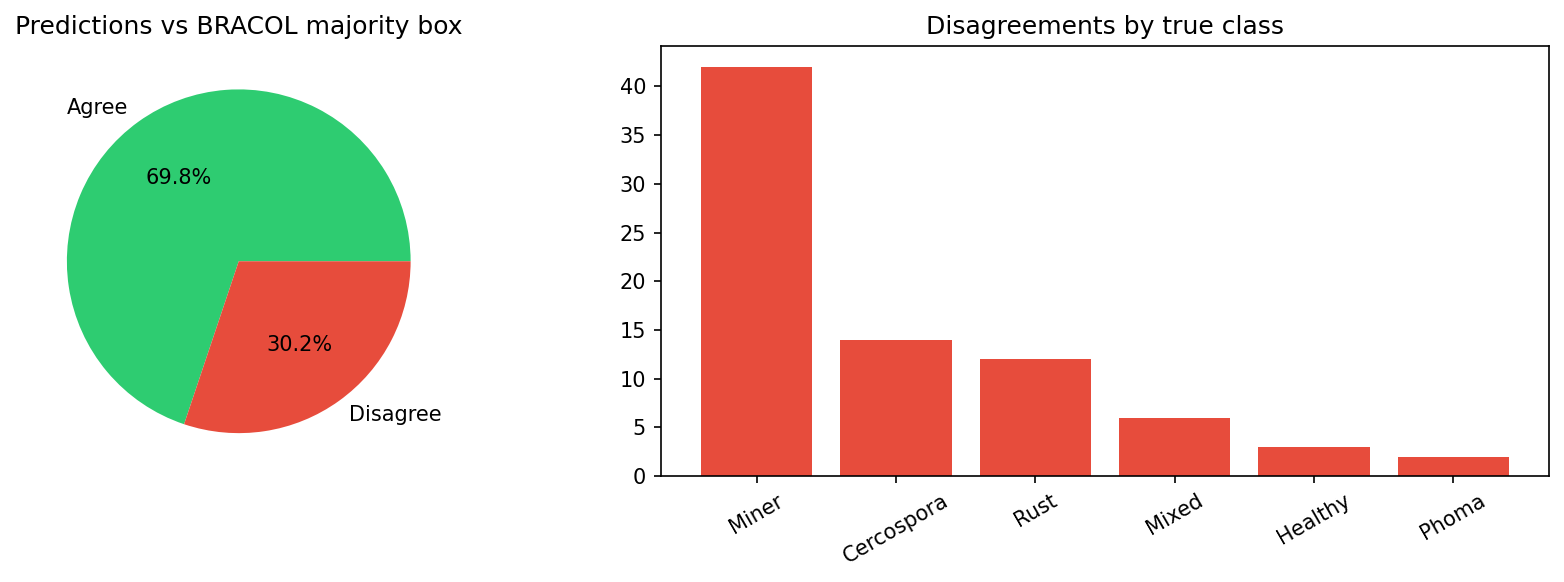

In [22]:
bracol = load_bracol_labels(PATHS["bracol_dir"])
print("BRACOL images with labels:", len(bracol))

test_ids = df.iloc[split.test_idx]["id"].values
best_preds = y_ens if "y_ens" in dir() else svm_deep.y_pred_test
y_true = svm_deep.y_true_test

rows_cmp = []
for i, img_id in enumerate(test_ids):
    if img_id not in bracol:
        continue
    dets = bracol[img_id]
    if len(dets) == 0:
        bracol_lab = 0
    else:
        most = max(set(dets), key=dets.count)
        bracol_lab = BRACOL_TO_STRESS.get(most, -1)
    rows_cmp.append({
        "id": int(img_id),
        "true": STRESS_NAMES.get(int(y_true[i]), str(y_true[i])),
        "ours": STRESS_NAMES.get(int(best_preds[i]), str(best_preds[i])),
        "bracol": STRESS_NAMES.get(int(bracol_lab), str(bracol_lab)),
        "n_det": len(dets),
        "multi_lesion": len(set(dets)) > 1,
        "agree": int(bracol_lab == best_preds[i]),
    })

comp = pd.DataFrame(rows_cmp)
if len(comp):
    print("Compared:", len(comp), "agreement:", float(comp["agree"].mean()))
    print("Errors where YOLO has multiple lesion types:",
          int(((comp["agree"] == 0) & comp["multi_lesion"]).sum()))
    comp.to_csv(os.path.join(PATHS["results_dir"], "bracol_crosscheck.csv"), index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].pie(
        [comp["agree"].sum(), (1 - comp["agree"]).sum()],
        labels=["Agree", "Disagree"], autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c"],
    )
    axes[0].set_title("Predictions vs BRACOL majority box")
    disagree = comp[comp["agree"] == 0]
    if len(disagree):
        vc = disagree["true"].value_counts()
        axes[1].bar(vc.index.astype(str), vc.values, color="#e74c3c")
        axes[1].tick_params(axis="x", rotation=30)
        axes[1].set_title("Disagreements by true class")
    fig.tight_layout()
    save_and_show(fig, "bracol_crosscheck.png", PATHS["figures_dir"])
else:
    print("No overlap with BRACOL labels. Folder missing or different filenames.")


## 12. Final results table and literature

Esgario et al. (2020), *Computers and Electronics in Agriculture*:

- Leaf **classification** set: 1,685 images, **five** classes (they dropped 62 mixed-equal leaves).
- Split: 70 / 15 / 15 (not 5-fold).
- ResNet50 single-task **95.63%** accuracy; multi-task **95.24%**, precision 95.29%, recall 91.14%.
- They crop the leaf with an HSV-S threshold before 224×224.

We use a 6-class label that includes Mixed. Missing leaf JPEGs are filled from Dataset Ninja and the Roboflow exports when those files exist. Those two facts, not architecture names, explain most of the gap versus Esgario.


                     model                   features  val_acc  test_acc  macro_f1                                                   best_params
                       SVM                handcrafted 0.645038  0.622137  0.470436              {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}
                       SVM       deep (frozen EffNet) 0.828244  0.820611  0.697977                  {'kernel': 'rbf', 'C': 100, 'gamma': 0.0001}
     SVM-linear (ablation)       deep (frozen EffNet) 0.820611  0.805344  0.683780                                {'kernel': 'linear', 'C': 0.1}
                       SVM               deep PCA-256 0.797710  0.790076  0.609060                  {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}
           EfficientNet-B0                 raw images 0.782443  0.767176  0.651728                {'lr': 0.0001, 'dropout': 0.3, 'unfreeze': 20}
                   XGBoost                handcrafted 0.778626  0.782443  0.600455  {'n_estimators': 200, 'max_depth': 5, 'learnin

'/mnt/c/Users/Alecs/PML/Project_1/figures/final_accuracy_bars.png'

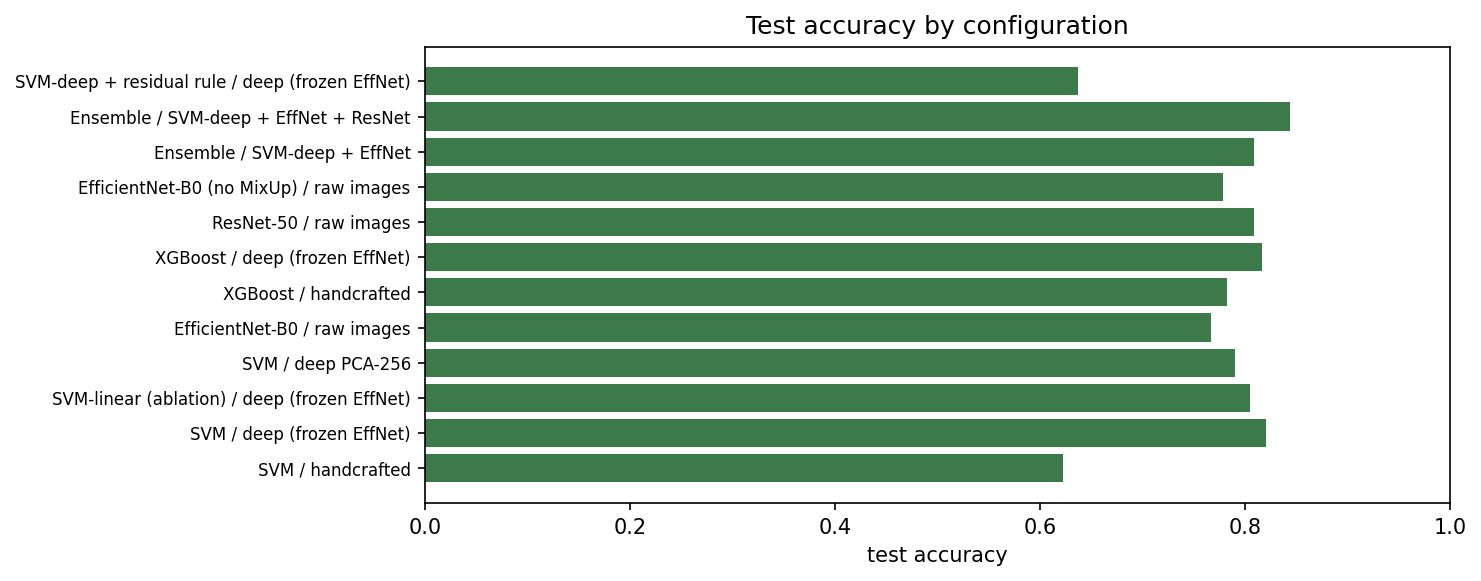

In [23]:
results_df = pd.DataFrame(results_rows())
results_df.to_csv(os.path.join(PATHS["results_dir"], "final_results.csv"), index=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = results_df.dropna(subset=["test_acc"]).copy()
labels = plot_df["model"] + " / " + plot_df["features"]
ax.barh(range(len(plot_df)), plot_df["test_acc"], color="#3d7a4a")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("test accuracy")
ax.set_xlim(0, 1)
ax.set_title("Test accuracy by configuration")
fig.tight_layout()
save_and_show(fig, "final_accuracy_bars.png", PATHS["figures_dir"])


## 13. Conclusions

- Two representations (handcrafted vs frozen CNN embeddings) and two official models (SVM, EfficientNet) are implemented end to end, each with its own ingest → fit → search → refit → report loop.
- The split is shared. Test is not used to pick hyperparameters.
- Mixed (class 5) is kept. The residual rule is an extra, not a replacement of the official 6-class task.
- ResNet-50 is the designated third method and the closest architecture family to Esgario et al. Numbers are not directly comparable (5 vs 6 classes, different image subset, they crop the leaf).
- MixUp follows Esgario's augmentation experiments; it is not presented as a new idea.

Next cell writes a compact JSON of the run so the report can copy numbers without re-typing them.


In [2]:
payload = {
    "n_csv": summary["n_csv"],
    "n_kept": summary["n_kept"],
    "n_missing": summary["n_missing"],
    "n_corrupt": summary["n_corrupt"],
    "split": split.sizes(),
    "results": results_rows(),
}
with open(os.path.join(PATHS["results_dir"], "run_summary.json"), "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, default=str)
print("Wrote results/run_summary.json")


NameError: name 'summary' is not defined